In [1]:
#Online Learning
# Import the online learning metrics and algorithms from the River library
!pip install river
import river
from river import metrics
from river import stream
from river import tree,neighbors,naive_bayes,ensemble,linear_model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from scipy.stats import shapiro
from imblearn.over_sampling import SMOTE
import time
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/IoT_2020_b_0.01.csv")
df

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Timestamp,Flow_Duration,TotLen_Fwd_Pkts,TotLen_Bwd_Pkts,Bwd_Pkt_Len_Max,...,Fwd_Pkts/s,Bwd_Pkts/s,Pkt_Len_Std,FIN_Flag_Cnt,Pkt_Size_Avg,Init_Bwd_Win_Byts,Idle_Mean,Idle_Max,Idle_Min,Label
0,12708,25886,53190,200,9020,3760,124,0.0,2776.0,1388.0,...,0.00,16129.03,0.00,0,2082.0,1869,124.00,124.0,124.0,1
1,60,25883,60357,110,7760,3649,46189,2528.0,0.0,0.0,...,43.30,43.30,698.97,0,632.0,126,15396.33,40225.0,1910.0,1
2,12695,25883,9020,203,52739,2261,73,1388.0,1388.0,1388.0,...,13698.63,13698.63,0.00,0,2082.0,1869,73.00,73.0,73.0,1
3,12690,25886,52717,200,9020,1963,149,0.0,0.0,0.0,...,13422.82,6711.41,0.00,0,0.0,32679,74.50,75.0,74.0,1
4,12690,25886,52717,200,9020,1905,83,0.0,0.0,0.0,...,12048.19,12048.19,0.00,0,0.0,32422,83.00,83.0,83.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,12659,25886,10125,200,9020,1057,70,0.0,2776.0,1388.0,...,0.00,28571.43,0.00,0,2082.0,1869,70.00,70.0,70.0,1
6248,13708,25883,60158,233,8899,3264,40,128.0,32.0,32.0,...,100000.00,25000.00,0.00,0,38.4,-1,10.00,21.0,5.0,1
6249,7655,15614,8487,200,554,3697,1283,0.0,0.0,0.0,...,0.00,1558.85,0.00,0,0.0,14600,1283.00,1283.0,1283.0,1
6250,62696,25889,64783,233,9988,3192,222,96.0,32.0,32.0,...,13513.51,4504.50,0.00,0,40.0,-1,74.00,206.0,8.0,1


# Automated Transformation/Encoding

In [5]:
#Automatically identify and transform string/text features into numerical features to make the data more readable by ML models
# Define the automated data encoding function
def Auto_Encoding(df):
    cat_features=[x for x in df.columns if df[x].dtype=="object"] ## Find string/text features
    le=LabelEncoder()
    for col in cat_features:
        if col in df.columns:
            i = df.columns.get_loc(col)
            # Transform to numerical features
            df.iloc[:,i] = df.apply(lambda i:le.fit_transform(i.astype(str)), axis=0, result_type='expand')
    return df
df=Auto_Encoding(df)

# Automated Imputation & Automated normalization

In [6]:
# Detect and impute missing values to improve data quality
# Define the automated data imputation function
def Auto_Imputation(df):
    if df.isnull().values.any() or np.isinf(df).values.any(): # if there is any empty or infinite values
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
        df.fillna(0, inplace = True)  # Replace empty values with zeros; there are other imputation methods discussed in the paper
    return df
df=Auto_Imputation(df)

#Normalize the range of features to a similar scale to improve data quality
def Auto_Normalization(df):
    stat, p = shapiro(df)
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    # interpret
    alpha = 0.05
    numeric_features = df.drop(['Label'],axis = 1).dtypes[df.dtypes != 'object'].index

    # check if the data distribution follows a Gaussian/normal distribution
    # If so, select the Z-score normalization method; otherwise, select the min-max normalization
    # Details are in the paper
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
        df[numeric_features] = df[numeric_features].apply(
            lambda x: (x - x.mean()) / (x.std()))
        print('Z-score normalization is automatically chosen and used')
    else:
        print('Sample does not look Gaussian (reject H0)')
        df[numeric_features] = df[numeric_features].apply(
            lambda x: (x - x.min()) / (x.max()-x.min()))
        print('Min-max normalization is automatically chosen and used')
    return df
df=Auto_Normalization(df)

Statistics=0.108, p=0.000
Sample does not look Gaussian (reject H0)
Min-max normalization is automatically chosen and used


# Automated Feature Engineering

Feature selection method 1: Information Gain (IG), used to remove irrelevant features to improve model efficiency

Feature selection method 2: Pearson Correlation, used to remove redundant features to improve model efficiency and accuracy

In [7]:
# Remove irrelevant features and select important features
def Feature_Importance_IG(data):
    features = data.drop(['Label'],axis=1).values  # "Label" should be changed to the target class variable name if different
    labels = data['Label'].values

    # Extract feature names
    feature_names = list(data.drop(['Label'],axis=1).columns)

    # Empty array for feature importances
    feature_importance_values = np.zeros(len(feature_names))
    model = lgb.LGBMRegressor(verbose = -1)
    model.fit(features, labels)
    feature_importances = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})

    # Sort features according to importance
    feature_importances = feature_importances.sort_values('importance', ascending = False).reset_index(drop = True)

    # Normalize the feature importances to add up to one
    feature_importances['normalized_importance'] = feature_importances['importance'] / feature_importances['importance'].sum()
    feature_importances['cumulative_importance'] = np.cumsum(feature_importances['normalized_importance'])

    cumulative_importance=0.90 # Only keep the important features with cumulative importance scores>=90%. It can be changed.

    # Make sure most important features are on top
    feature_importances = feature_importances.sort_values('cumulative_importance')

    # Identify the features not needed to reach the cumulative_importance
    record_low_importance = feature_importances[feature_importances['cumulative_importance'] > cumulative_importance]

    to_drop = list(record_low_importance['feature'])
#     print(feature_importances.drop(['importance'],axis=1))
    return to_drop
# Remove redundant features
def Feature_Redundancy_Pearson(data):
    correlation_threshold=0.90 # Only remove features with the redundancy>90%. It can be changed
    features = data.drop(['Label'],axis=1)
    corr_matrix = features.corr()

    # Extract the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(np.bool))

    # Select the features with correlations above the threshold
    # Need to use the absolute value
    to_drop = [column for column in upper.columns if any(upper[column].abs() > correlation_threshold)]

    # Dataframe to hold correlated pairs
    record_collinear = pd.DataFrame(columns = ['drop_feature', 'corr_feature', 'corr_value'])

    # Iterate through the columns to drop
    for column in to_drop:

        # Find the correlated features
        corr_features = list(upper.index[upper[column].abs() > correlation_threshold])

        # Find the correlated values
        corr_values = list(upper[column][upper[column].abs() > correlation_threshold])
        drop_features = [column for _ in range(len(corr_features))]

        # Record the information (need a temp df for now)
        temp_df = pd.DataFrame.from_dict({'drop_feature': drop_features,
                                         'corr_feature': corr_features,
                                         'corr_value': corr_values})
        record_collinear = record_collinear.append(temp_df, ignore_index = True)
#     print(record_collinear)
    return to_drop
def Auto_Feature_Engineering(df):
    drop1 = Feature_Importance_IG(df)
    dfh1 = df.drop(columns = drop1)

    drop2 = Feature_Redundancy_Pearson(dfh1)
    dfh2 = dfh1.drop(columns = drop2)

    return dfh2
dfh2 = Auto_Feature_Engineering(df)
dfh2

,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Timestamp,Flow_Duration,TotLen_Bwd_Pkts,Flow_Byts/s,Flow_Pkts/s,Flow_IAT_Std,Fwd_IAT_Tot,Bwd_IAT_Std,Bwd_Pkts/s,Pkt_Len_Std,Init_Bwd_Win_Byts,Idle_Mean,Label
0,0.198248,0.446464,0.821049,0.413136,0.148302,0.874767,0.001241,0.123680,0.220603,0.006440,0.000000,0.000000,0.0,0.016109,0.000000,0.028534,0.002506,1
1,0.000765,0.446413,0.931680,0.222458,0.127585,0.848929,0.466032,0.000000,0.000539,0.000023,0.336694,0.458352,0.0,0.000023,0.829215,0.001938,0.311194,1
2,0.198045,0.446413,0.139234,0.419492,0.867104,0.525838,0.000726,0.061840,0.374723,0.010947,0.000000,0.000000,0.0,0.013679,0.000000,0.028534,0.001475,1
3,0.197967,0.446464,0.813747,0.413136,0.148302,0.456471,0.001493,0.000000,0.000000,0.008042,0.000011,0.000843,0.0,0.006691,0.000000,0.498657,0.001506,1
4,0.197967,0.446464,0.813747,0.413136,0.148302,0.442970,0.000827,0.000000,0.000000,0.009627,0.000000,0.000000,0.0,0.012028,0.000000,0.494736,0.001678,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6247,0.197483,0.446464,0.156291,0.413136,0.148302,0.245577,0.000696,0.123680,0.390782,0.011417,0.000000,0.000000,0.0,0.028552,0.000000,0.028534,0.001415,1
6248,0.213862,0.446413,0.928608,0.483051,0.146312,0.759311,0.000394,0.001426,0.039416,0.049988,0.000116,0.000216,0.0,0.024980,0.000000,0.000000,0.000202,1
6249,0.119352,0.269300,0.131007,0.413136,0.009109,0.860102,0.012935,0.000000,0.000000,0.000611,0.000000,0.000000,0.0,0.001539,0.000000,0.222794,0.025932,1
6250,0.978750,0.446516,1.000000,0.483051,0.164217,0.742551,0.002230,0.001426,0.005682,0.007195,0.001788,0.000182,0.0,0.004484,0.000000,0.000000,0.001496,1



#Train-test split

Split the dataset into the training and the test set

Here we used the 0.1%/99.9% split, because for online learning, the initial available data would only be a small percentage, and the incoming data streams will be continously learned by the data analytics models. It can be changed based on specific tasks

In [8]:
X = dfh2.drop(['Label'],axis=1)
y = dfh2['Label']

X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.001, test_size = 0.999, shuffle=False,random_state = 0)



# Adding Cost-aware Adversarial Functions

In [9]:
import copy
import numpy as np

# Define feature costs (all 1.0 for demo, but custom if needed)
feature_costs = {col: 1.0 for col in X_train.columns}

# Get feature ranges for each feature (for adversarial perturbations)
feature_ranges = {
    col: (X_train[col].min(), X_train[col].max())
    for col in X_train.columns
}
cost_budget = 0.2 * len(feature_costs)  # Example: budget to modify up to 20% of features

def cost_aware_adversarial_example(x, y_true, model, feature_costs, cost_budget, feature_ranges):
    x_adv = copy.deepcopy(x)
    total_cost = 0.0

    for feature in x_adv.keys():
        if total_cost + feature_costs[feature] > cost_budget:
            continue

        orig_value = x[feature]
        # For numeric features only
        if np.issubdtype(type(orig_value), np.number):
            delta = (feature_ranges[feature][1] - feature_ranges[feature][0]) * 0.2
            # Try +delta and -delta
            candidates = [orig_value + delta, orig_value - delta]
            best_candidate = orig_value
            max_loss = -1
            for cand in candidates:
                cand_clipped = np.clip(cand, feature_ranges[feature][0], feature_ranges[feature][1])
                x_test = copy.deepcopy(x_adv)
                x_test[feature] = cand_clipped
                y_pred = model.predict_one(x_test)
                loss = int(y_pred != y_true)  # 1 for wrong, 0 for correct
                if loss > max_loss:
                    max_loss = loss
                    best_candidate = cand_clipped
            if max_loss > int(model.predict_one(x_adv) != y_true):
                x_adv[feature] = best_candidate
                total_cost += feature_costs[feature]
        if total_cost >= cost_budget:
            break
    return x_adv




# Modified adaptive learning function (replace adaptive_learning)
from river import metrics, stream
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def adaptive_learning_adv(model, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges):
    metric = metrics.Accuracy()
    t, m = [], []
    yt, yp = [], []

    # Learn the training set (augmented)
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi1)

    # Predict the test set (vanilla)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        # Optionally: train on adversarial in test set too
        x_adv = cost_aware_adversarial_example(dict(xi), yi, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)
    print("Accuracy: "+str(round(accuracy_score(yt,yp),5)*100)+"%")
    print("Precision: "+str(round(precision_score(yt,yp),5)*100)+"%")
    print("Recall: "+str(round(recall_score(yt,yp),5)*100)+"%")
    print("F1-score: "+str(round(f1_score(yt,yp),5)*100)+"%")
    return t, m

# LEAVE THIS PART FOR NOW

# 3. Model Learning

Four state-of-the-art online learners:
•	Hoeffding Tree (HT)
•	Leveraging Bagging (LB)
•	Adaptive Random Forest (ARF)
•	Streaming Random Patches (SRP)

In [12]:
import matplotlib.pyplot as plt

def acc_fig(t_values, m_values, name):
    # This is a placeholder function for plotting accuracy over time.
    # You can customize this function to create the desired visualization.
    print(f"Plotting accuracy for {name} (Placeholder function)")
    plt.figure(figsize=(10, 6))
    plt.plot(t_values, m_values, label=name)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.title(f'Accuracy over time for {name}')
    plt.legend()
    plt.grid(True)
    plt.show()

Online Learning

Accuracy: 96.814%
Precision: 97.07000000000001%
Recall: 99.626%
F1-score: 98.331%
Plotting accuracy for HT model (adv-trained) (Placeholder function)


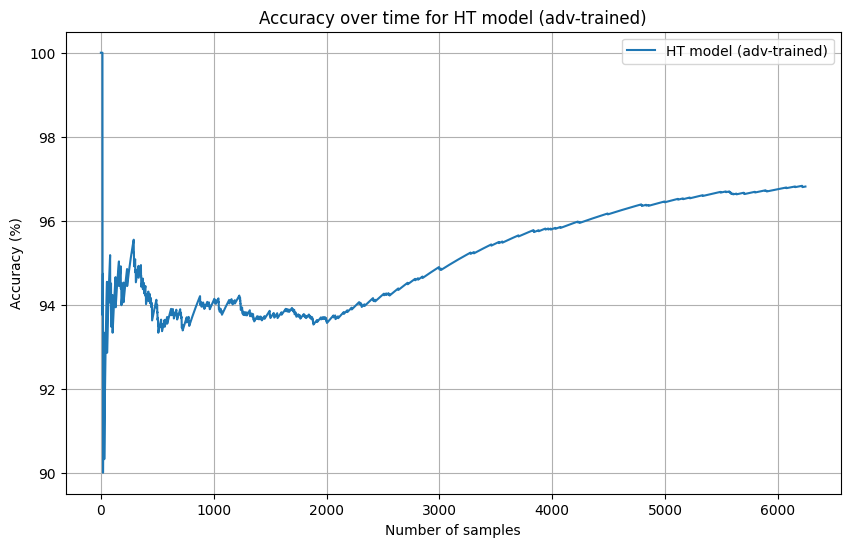

CPU times: user 17 s, sys: 25 ms, total: 17 s
Wall time: 20.9 s


In [13]:
%%time
name1 = "HT model (adv-trained)"
model1 = tree.HoeffdingTreeClassifier()
t, m1 = adaptive_learning_adv(model1, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m1, name1)

Accuracy: 98.76700000000001%
Precision: 98.872%
Recall: 99.83%
F1-score: 99.349%
Plotting accuracy for LB model (adv-trained) (Placeholder function)


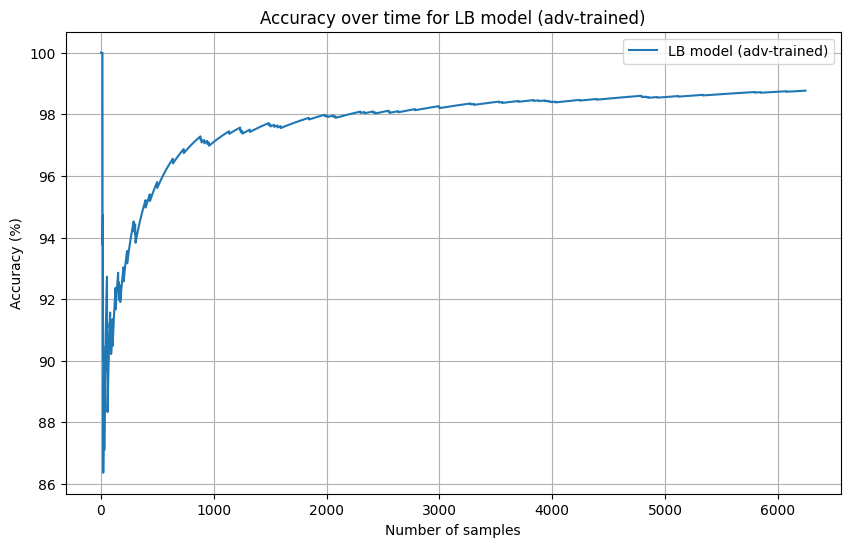

CPU times: user 49.5 s, sys: 222 ms, total: 49.7 s
Wall time: 51.7 s


In [21]:
%%time
# Use the Leveraging Bagging (LB) model (adv-trained)
name2 = "LB model (adv-trained)"
model2 = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t, m2 = adaptive_learning_adv(model2, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m2, name2)

In [23]:

%time
# Use the Adaptive Random Forest (ARF) model (adv-trained)
name2 = "ARF model (adv-trained)"
from river import ensemble
model3 = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t, m2 = adaptive_learning_adv(model2, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m2, name2)

CPU times: user 5 µs, sys: 0 ns, total: 5 µs
Wall time: 7.63 µs


AttributeError: module 'river.ensemble' has no attribute 'AdaptiveRandomForestClassifier'

Accuracy: 98.97500000000001%
Precision: 99.122%
Recall: 99.79599999999999%
F1-score: 99.458%
Plotting accuracy for SRP model (adv-trained) (Placeholder function)


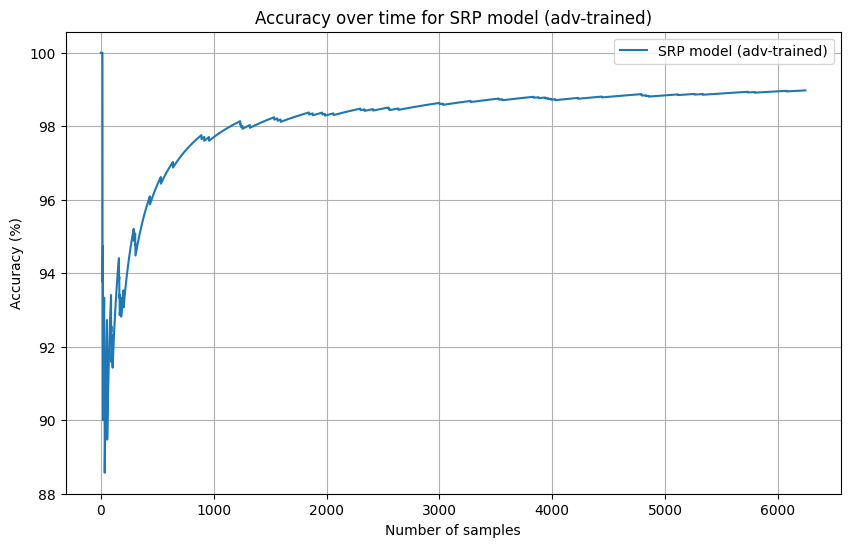

CPU times: user 49.7 s, sys: 331 ms, total: 50.1 s
Wall time: 50.4 s


In [23]:
%%time
# Use the Streaming Random Patches (SRP) model (adv-trained) with ADWIN drift detector
name4 = "SRP model (adv-trained)"
model4 = ensemble.SRPClassifier(n_models=3)
t, m4 = adaptive_learning_adv(model4, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m4, name4)

NameError: name 'm3' is not defined

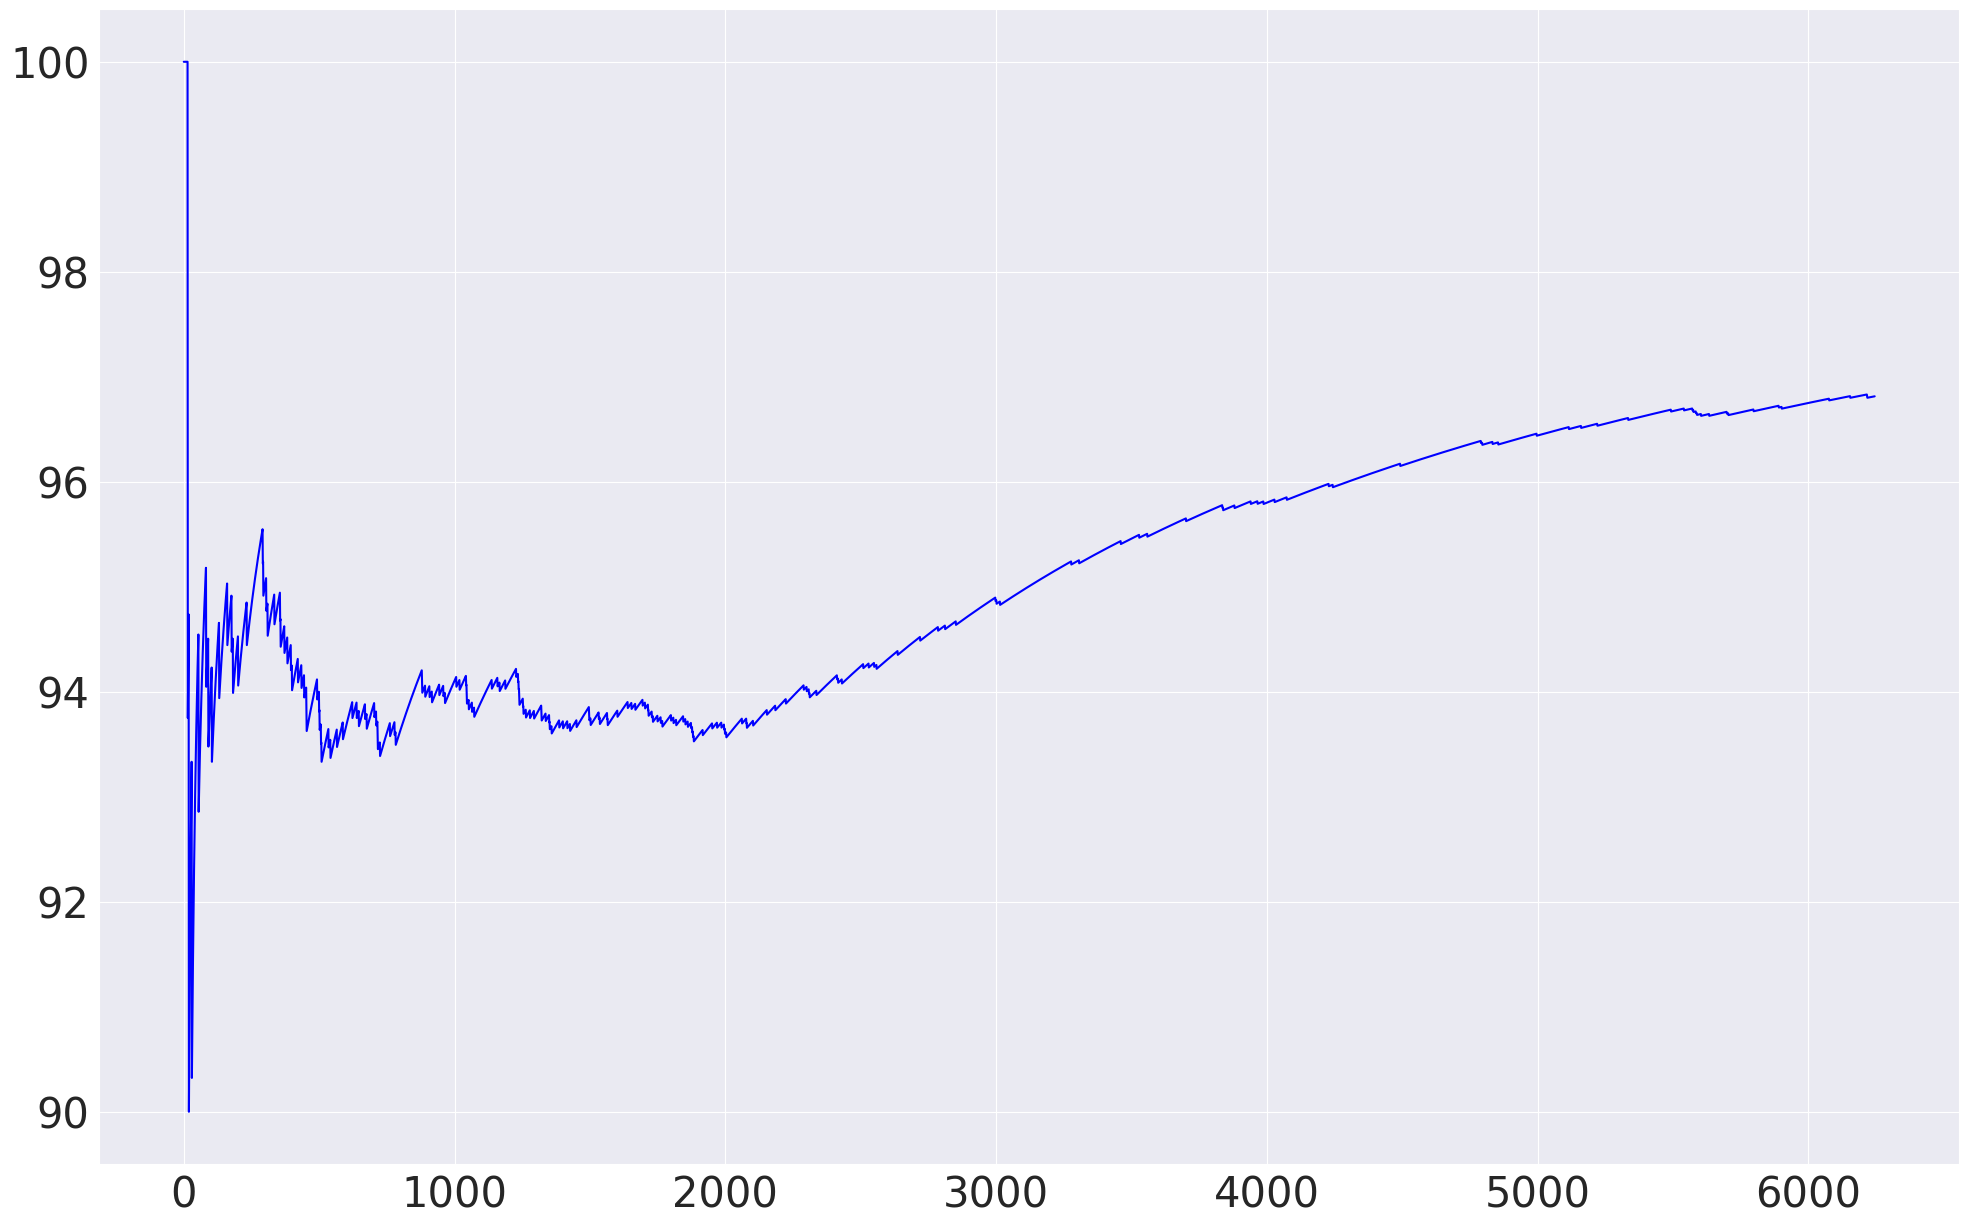

In [16]:
# Draw a comprehensive figure to compare the performance of all models
plt.rcParams.update({'font.size': 30})
plt.figure(1,figsize=(24,15))
sns.set_style("darkgrid")
plt.clf()

# Plot the accuracy change of each learner
plt.plot(t,m1,'-b',label=name1+', Avg Accuracy: %.2f%%'%(m1[-1]))
plt.plot(t,m2,'-g',label=name2+', Avg Accuracy: %.2f%%'%(m2[-1]))
plt.plot(t,m3,'orange',label=name3+', Avg Accuracy: %.2f%%'%(m3[-1]))
plt.plot(t,m4,'black',label=name4+', Avg Accuracy: %.2f%%'%(m4[-1]))

# Draw the drift points/time
dr = [0,270,600]
for i in range(len(dr)):
    if i!=0:
        plt.text(dr[i]-200, 100.2, 'Drift '+str(i), c = "red", fontsize = 25)
        plt.vlines(dr[i], 0, 100, colors = "red", linewidth=4, linestyles = "dashed")

plt.legend(loc='lower right')
plt.ylim(85, 100.8)
plt.title('IoTID20', fontsize=40)
plt.xlabel('Number of samples')
plt.ylabel('Accuracy (%)')

plt.draw()

# Automated Online Learning Model Selection

Select the best-performing model among four state-of-the-art online learning models (HT, LB, ARF, and SRP) by evaluating their learning performance

In [22]:
def adaptive_learning_model_selection_adv(model_list, X_train, y_train, X_test, y_test,
                                         feature_costs, cost_budget, feature_ranges):
    from river import metrics, stream
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

    i = 0  # count the number of evaluated data points (shared for all models)
    t = []
    m = []
    yt = []
    yp = []
    ypb = []
    acc_b = 0
    mb = []
    model_b = None

    for model in model_list:
        # 1. Train with adversarial examples
        for xi1, yi1 in stream.iter_pandas(X_train, y_train):
            model.learn_one(dict(xi1), yi1)
            x_adv = cost_aware_adversarial_example(dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges)
            model.learn_one(x_adv, yi1)

        # 2. Evaluate on test set
        metric = metrics.Accuracy() # This line initializes metric for each model in model_list
        t_tmp, m_tmp, yt_tmp, yp_tmp = [], [], [], []
        for j, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
            y_pred = model.predict_one(dict(xi))
            model.learn_one(dict(xi), yi)
            # You could adversarial-train on test set too (optional, consistency with train)
            x_adv = cost_aware_adversarial_example(dict(xi), yi, model, feature_costs, cost_budget, feature_ranges)
            model.learn_one(x_adv, yi)

            metric.update(yi, y_pred) # Fixed: Removed reassignment of metric
            t_tmp.append(j)
            m_tmp.append(metric.get()*100) # This is where the error occurs
            yt_tmp.append(yi)
            yp_tmp.append(y_pred)

        if accuracy_score(yt_tmp, yp_tmp) > acc_b:
            acc_b = accuracy_score(yt_tmp, yp_tmp)
            mb = m_tmp
            ypb = yp_tmp
            yt = yt_tmp
            t = t_tmp
            model_b = model

    print(model_b)
    print("Accuracy: "+str(round(accuracy_score(yt, ypb),5)*100)+"%")
    print("Precision: "+str(round(precision_score(yt, ypb),5)*100)+"%")
    print("Recall: "+str(round(recall_score(yt, ypb),5)*100)+"%")
    print("F1-score: "+str(round(f1_score(yt, ypb),5)*100)+"%")
    return t, mb

In [23]:
model1 = tree.HoeffdingTreeClassifier()
model2 = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(),n_models=3)
# Based on previous context, using LB as substitute for ARF
model3 = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
model4 = ensemble.SRPClassifier(n_models=3)
model_list = [model1, model2, model3, model4]

t, mb = adaptive_learning_model_selection_adv(
    model_list, X_train, y_train, X_test, y_test,
    feature_costs, cost_budget, feature_ranges
)

SRPClassifier(HoeffdingTreeClassifier)
Accuracy: 99.007%
Precision: 99.10600000000001%
Recall: 99.847%
F1-score: 99.47500000000001%


# Hyperparameter Optimization

Optimize the best performing online learning model (SRP) by tuning its hyperparameters

In [24]:
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Define the objective function
def objective(params):
    params = {
        'n_models': int(params['n_models']),
        'subspace_size': abs(float(params['subspace_size'])),
    }
    clf = ensemble.SRPClassifier( **params)

    #t, m = adaptive_learning(clf, X_train, y_train, X_test, y_test)
    t, m = adaptive_learning_adv(clf, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)

    return {'loss':-m[-1], 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_models': hp.quniform('n_models', 2, 10, 1),
    "subspace_size":hp.uniform('subspace_size', 0.3, 1),
}

# Detect the optimal hyperparameter values
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=10)
print("SRP: Hyperopt estimated optimum {}".format(best))




Accuracy: 99.264%
Precision: 99.324%
Recall: 99.898%
F1-score: 99.61%
Accuracy: 98.911%
Precision: 99.055%
Recall: 99.79599999999999%
F1-score: 99.424%
Accuracy: 99.055%
Precision: 99.206%
Recall: 99.79599999999999%
F1-score: 99.5%
Accuracy: 99.007%
Precision: 99.10600000000001%
Recall: 99.847%
F1-score: 99.47500000000001%
Accuracy: 99.087%
Precision: 99.24%
Recall: 99.79599999999999%
F1-score: 99.517%
Accuracy: 99.29599999999999%
Precision: 99.374%
Recall: 99.881%
F1-score: 99.627%
Accuracy: 99.215%
Precision: 99.25699999999999%
Recall: 99.91499999999999%
F1-score: 99.58500000000001%
Accuracy: 98.815%
Precision: 99.104%
Recall: 99.643%
F1-score: 99.373%
Accuracy: 99.087%
Precision: 99.157%
Recall: 99.881%
F1-score: 99.517%
Accuracy: 99.103%
Precision: 99.206%
Recall: 99.847%
F1-score: 99.52600000000001%
100%|██████████| 10/10 [14:51<00:00, 89.11s/trial, best loss: -99.29554915145692]
SRP: Hyperopt estimated optimum {'n_models': np.float64(7.0), 'subspace_size': np.float64(0.3862136256

# Testing the AUTOML Part using Evasion (Test time) Attacks

How to Use:
Just run this cell after you have trained your model.
If you want to test with your best model, use it in place of model.
If you want to test a baseline, use a clean/non-adv-trained model as input.
What You Get
Prints test accuracy under clean (unchanged) and adversarial (attacked) test samples for each budget.
Graph: Visualizes decrease in accuracy as attack strength grows.

# Batch dimesnion of the River AutoML

 When you do one batch of training (even with an online learner!) on a static train set, then evaluate on a static test set (clean or adversarial), you are NOT doing a full "online" streaming evaluation—you are using a river model in "batch" (AutoML) mode.

# Do this after Setting up cost, feature

# Hoeffding Tree

In [29]:
from river import tree, ensemble
model1 = tree.HoeffdingTreeClassifier()

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6))
    sns.set_style("darkgrid")
    plt.clf()
    plt.plot(t, m, '-b', label='Avg Accuracy: %.2f%%' % (m[-1]))
    plt.legend(loc='best')
    plt.title(name+' on IoTID20 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.draw()
    plt.show()

Accuracy: 96.814%
Precision: 97.07000000000001%
Recall: 99.626%
F1-score: 98.331%


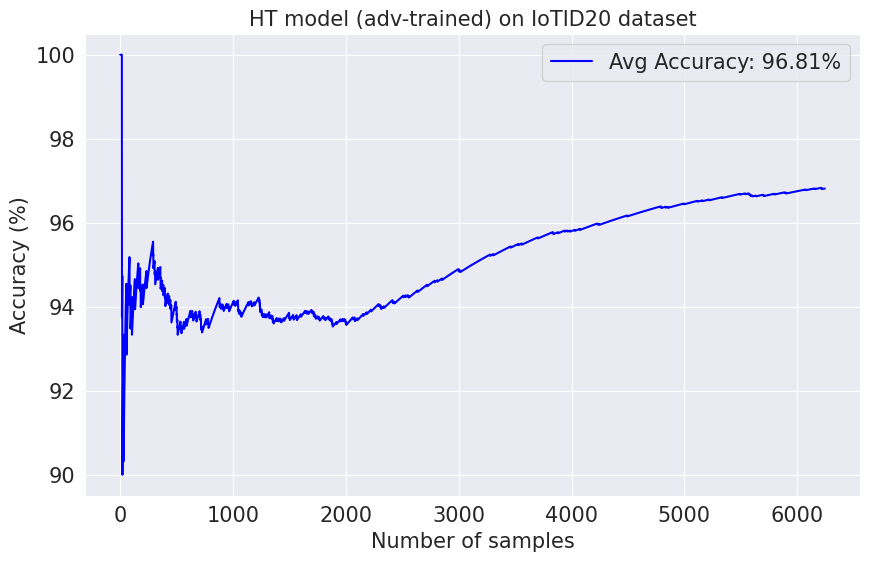

CPU times: user 12 s, sys: 13 ms, total: 12 s
Wall time: 12.1 s


In [31]:
%%time
name1 = "HT model (adv-trained)"
model1 = tree.HoeffdingTreeClassifier()
t, m1 = adaptive_learning_adv(model1, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m1, name1)


Cost budget=0.00: Clean acc=0.9872, Adv acc=0.9872
Cost budget=0.05: Clean acc=0.9872, Adv acc=0.9872
Cost budget=0.10: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.20: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.40: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.80: Clean acc=0.9872, Adv acc=0.9632
Cost budget=1.00: Clean acc=0.9872, Adv acc=0.9632


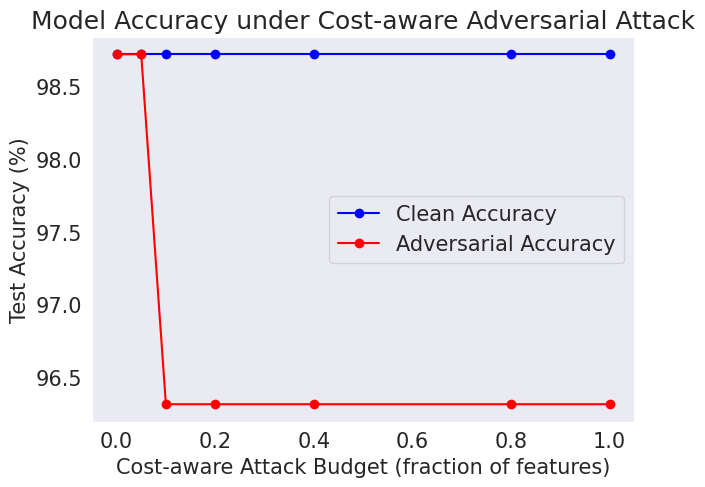

   Attack Budget  Clean Accuracy  Adv Accuracy
0           0.00        0.987192      0.987192
1           0.05        0.987192      0.987192
2           0.10        0.987192      0.963176
3           0.20        0.987192      0.963176
4           0.40        0.987192      0.963176
5           0.80        0.987192      0.963176
6           1.00        0.987192      0.963176


In [33]:
# ASSIGN the trained model
model = model1

import numpy as np
import matplotlib.pyplot as plt
from river import stream
from sklearn.metrics import accuracy_score

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results = []

for frac in budgets:
    adv_budget = frac * len(feature_costs)
    y_true, y_pred_clean, y_pred_adv = [], [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        dict_xi = dict(xi)
        y_pred = model.predict_one(dict_xi)
        x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
        y_pred_a = model.predict_one(x_adv)
        y_true.append(yi)
        y_pred_clean.append(y_pred)
        y_pred_adv.append(y_pred_a)
    clean_acc = accuracy_score(y_true, y_pred_clean)
    adv_acc = accuracy_score(y_true, y_pred_adv)
    results.append((frac, clean_acc, adv_acc))
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")

# Plotting:
results = np.array(results)
plt.figure(figsize=(7,5))
plt.plot(results[:,0], results[:,1]*100, 'bo-', label='Clean Accuracy')
plt.plot(results[:,0], results[:,2]*100, 'ro-', label='Adversarial Accuracy')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('Model Accuracy under Cost-aware Adversarial Attack')
plt.legend()
plt.grid()
plt.show()

import pandas as pd
df_results = pd.DataFrame(results, columns=['Attack Budget', 'Clean Accuracy', 'Adv Accuracy'])
print(df_results)

## Train the NON-adversarially-trained model

In [49]:
from river import tree, ensemble
model1_naive = tree.HoeffdingTreeClassifier()

import matplotlib.pyplot as plt
import seaborn as sns

def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6))
    sns.set_style("darkgrid")
    plt.clf()
    plt.plot(t, m, '-b', label='Avg Accuracy: %.2f%%' % (m[-1]))
    plt.legend(loc='best')
    plt.title(name+' on IoTID20 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.draw()
    plt.show()


Accuracy: 98.92699999999999%
Precision: 99.288%
Recall: 99.575%
F1-score: 99.432%


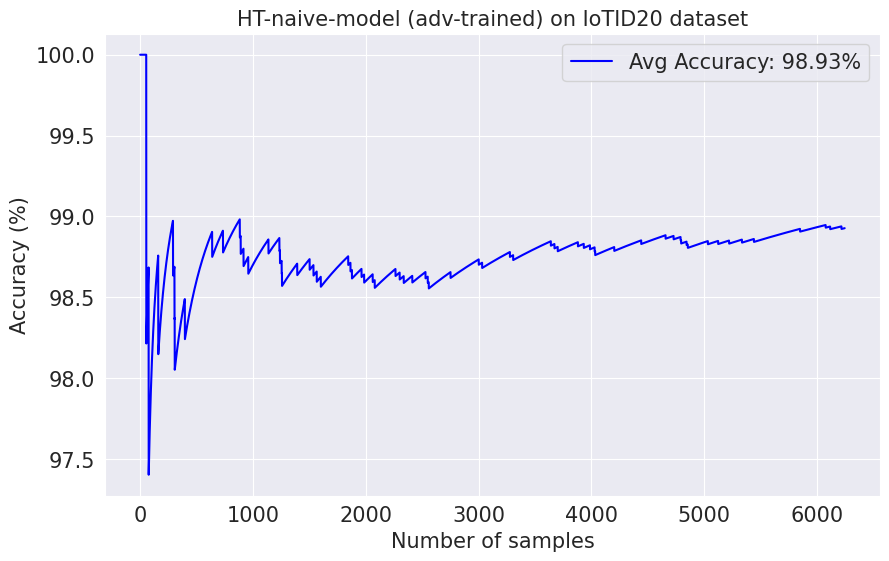

CPU times: user 11.5 s, sys: 34.9 ms, total: 11.5 s
Wall time: 11.6 s


In [50]:
%%time
name1 = "HT-naive-model (adv-trained)"
model1_naive = tree.HoeffdingTreeClassifier()
t, m1 = adaptive_learning_adv(model1, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t, m1, name1)

In [51]:
model = model1_naive

# This function trains the model normally (i.e. without adversarial examples in train)
def adaptive_learning(model, X_train, y_train, X_test, y_test):
    metric = metrics.Accuracy()
    t, m = [], []
    yt, yp = [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)
    print("Accuracy: "+str(round(accuracy_score(yt,yp),5)*100)+"%")
    print("Precision: "+str(round(precision_score(yt,yp),5)*100)+"%")
    print("Recall: "+str(round(recall_score(yt,yp),5)*100)+"%")
    print("F1-score: "+str(round(f1_score(yt,yp),5)*100)+"%")
    return t, m

# Train it
t_naive, m_naive = adaptive_learning(model1_naive, X_train, y_train, X_test, y_test)

Accuracy: 95.72500000000001%
Precision: 95.959%
Recall: 99.66000000000001%
F1-score: 97.774%


In [52]:
budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = []

model = model1_naive  # or model1_naive, model2_naive etc. as trained

for frac in budgets:
    adv_budget = frac * len(feature_costs)
    y_true, y_pred_clean, y_pred_adv = [], [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        dict_xi = dict(xi)
        y_pred = model.predict_one(dict_xi)
        x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
        y_pred_a = model.predict_one(x_adv)
        y_true.append(yi)
        y_pred_clean.append(y_pred)
        y_pred_adv.append(y_pred_a)
    clean_acc = accuracy_score(y_true, y_pred_clean)
    adv_acc = accuracy_score(y_true, y_pred_adv)
    results_naive.append((frac, clean_acc, adv_acc))
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")

Cost budget=0.00: Clean acc=0.9862, Adv acc=0.9862
Cost budget=0.05: Clean acc=0.9862, Adv acc=0.9862
Cost budget=0.10: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.20: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.40: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.80: Clean acc=0.9862, Adv acc=0.9036
Cost budget=1.00: Clean acc=0.9862, Adv acc=0.9036


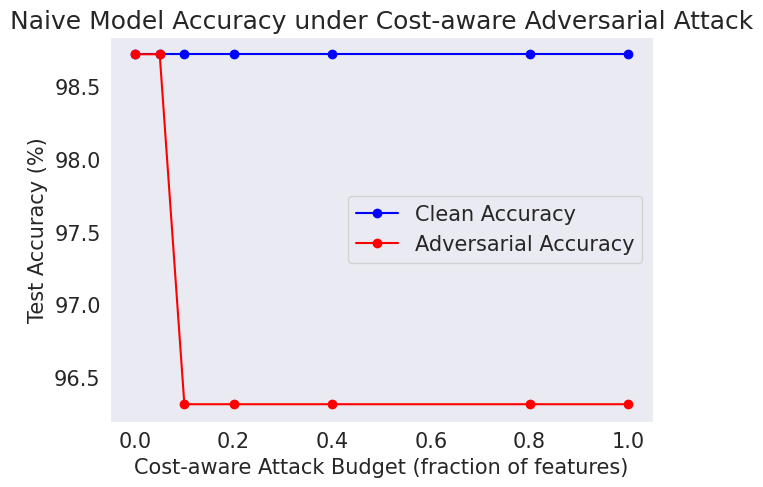

In [48]:

results_naive = np.array(results_naive)
plt.figure(figsize=(7,5))
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'bo-', label='Clean Accuracy')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'ro-', label='Adversarial Accuracy')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('Naive Model Accuracy under Cost-aware Adversarial Attack')
plt.legend()
plt.grid()
plt.show()

Plot both results together for direct visual comparison


If your adversarially-trained model’s results are named results and your naive model’s results are results_naive, do:

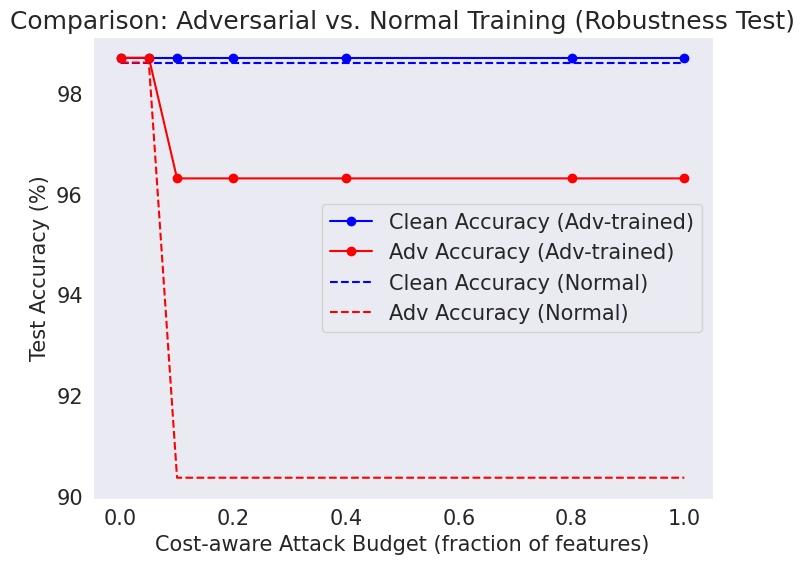

In [44]:
results = np.array(results)                # Results for adv-trained model
results_naive = np.array(results_naive)    # Now this will be defined

plt.figure(figsize=(8,6))
plt.plot(results[:,0], results[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results[:,0], results[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Normal)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Normal)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison: Adversarial vs. Normal Training (Robustness Test)')
plt.legend()
plt.grid()
plt.show()

# WHAT TO NOTE:

You accidentally reused model1_naive with both adversarial and non-adversarial training!
If you call adaptive_learning_adv, then adaptive_learning on the same model (model1_naive), the second training will happen on a model that already saw adversarial examples!
The evaluation is no longer purely on a naive/non-adversarially-trained model.

*   Run adaptive_learning with model1_naive
*   Run adaptive_learning_adv with model1_adv
Evaluate each model SEPARATELY


# A MORE COMPACT WAY OF RUNNING THE CODES.

The separate one above showed the same result with this compact one.

# Hoeffding Tree Model and Compact Model


==== Hoeffding Tree NAIVE Model Metrics ====
Accuracy:  95.725%
Precision: 95.959%
Recall:    99.66%
F1-score:  97.774%



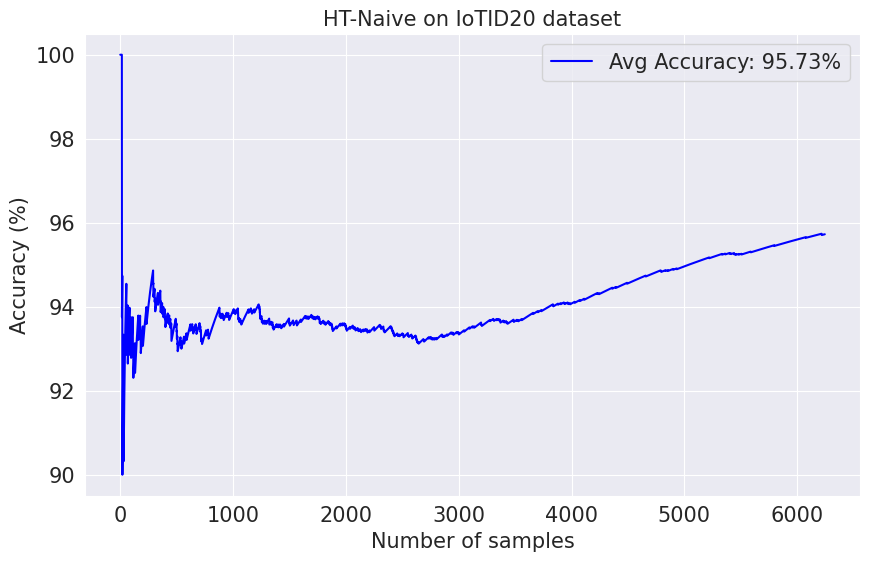


==== Hoeffding Tree ADVERSARIALLY-TRAINED Model Metrics ====
Accuracy:  96.814%
Precision: 97.07%
Recall:    99.626%
F1-score:  98.331%



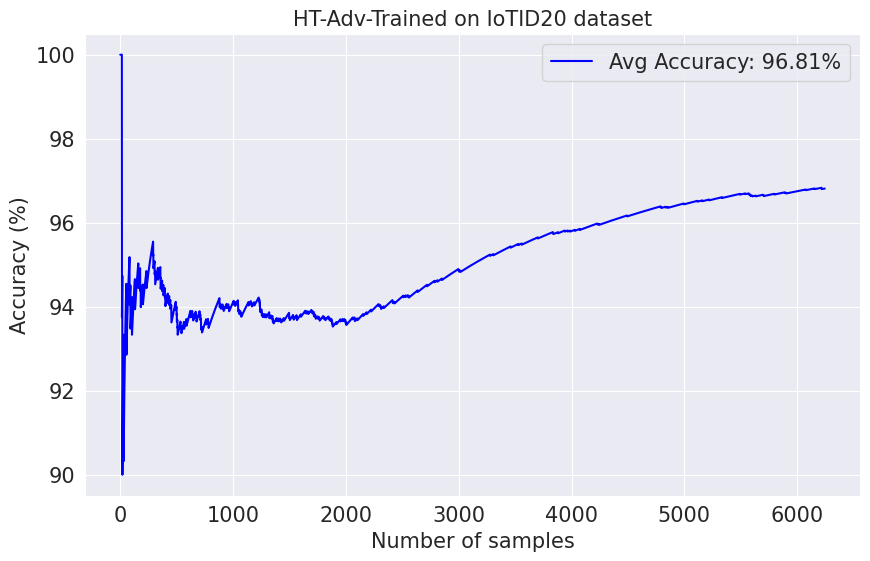

==== Cost-aware Adversarial Test: HOEFFDING TREE (NAIVE) ====
Cost budget=0.00: Clean acc=0.9862, Adv acc=0.9862
Cost budget=0.05: Clean acc=0.9862, Adv acc=0.9862
Cost budget=0.10: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.20: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.40: Clean acc=0.9862, Adv acc=0.9036
Cost budget=0.80: Clean acc=0.9862, Adv acc=0.9036
Cost budget=1.00: Clean acc=0.9862, Adv acc=0.9036

==== Cost-aware Adversarial Test: HOEFFDING TREE (ADV-TRAINED) ====
Cost budget=0.00: Clean acc=0.9872, Adv acc=0.9872
Cost budget=0.05: Clean acc=0.9872, Adv acc=0.9872
Cost budget=0.10: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.20: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.40: Clean acc=0.9872, Adv acc=0.9632
Cost budget=0.80: Clean acc=0.9872, Adv acc=0.9632
Cost budget=1.00: Clean acc=0.9872, Adv acc=0.9632



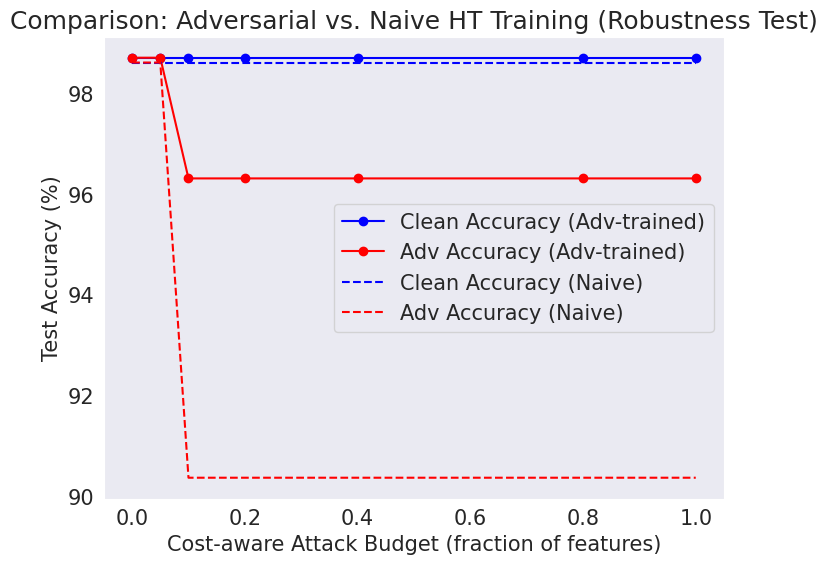

In [9]:
from river import tree, stream, metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6))
    sns.set_style("darkgrid")
    plt.clf()
    plt.plot(t, m, '-b', label='Avg Accuracy: %.2f%%' % (m[-1]))
    plt.legend(loc='best')
    plt.title(name+' on IoTID20 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.draw()
    plt.show()

# --- Standard training (naive model) ---
def adaptive_learning(model, X_train, y_train, X_test, y_test):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== Hoeffding Tree NAIVE Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Adversarial training (adv-trained model) ---
def adaptive_learning_adv(model, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        x_adv = cost_aware_adversarial_example(dict(xi), yi, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== Hoeffding Tree ADVERSARIALLY-TRAINED Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Train models ---
model1_naive = tree.HoeffdingTreeClassifier()
t_naive, m_naive, _, _, _, _ = adaptive_learning(model1_naive, X_train, y_train, X_test, y_test)
acc_fig(t_naive, m_naive, "HT-Naive")

model1_adv = tree.HoeffdingTreeClassifier()
t_adv, m_adv, _, _, _, _ = adaptive_learning_adv(model1_adv, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t_adv, m_adv, "HT-Adv-Trained")

# --- Evaluation under attack ---
def eval_under_attack(model, budgets, feature_costs, feature_ranges):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict_xi)
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model1_naive, budgets, feature_costs, feature_ranges)
results_adv = eval_under_attack(model1_adv, budgets, feature_costs, feature_ranges)

# ---- Print attack robustness with headings ---
print("==== Cost-aware Adversarial Test: HOEFFDING TREE (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=============================================================\n")

print("==== Cost-aware Adversarial Test: HOEFFDING TREE (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("===================================================================\n")

# --- Plot ---
plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison: Adversarial vs. Naive HT Training (Robustness Test)')
plt.legend()
plt.grid()
plt.show()

# Hoeffding Tree with Time Metrics Alone

In [11]:
!pip install memory_profiler

from river import tree, stream
from memory_profiler import memory_usage
import time

# --- NAIVE HT TRAINING PROFILED ---
model1_naive = tree.HoeffdingTreeClassifier()

def train_naive_ht():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model1_naive.learn_one(dict(xi1), yi1)

t0 = time.perf_counter()
peak_mem_train_naive = memory_usage((train_naive_ht,), max_usage=True, retval=False)
train_wall_naive = time.perf_counter() - t0
print(f"[NAIVE-HT] Training wall time (s): {train_wall_naive:.4f} | Peak mem.: {peak_mem_train_naive:.2f} MB")

# --- NAIVE HT PREDICTION PROFILED ---
def pred_naive_ht():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model1_naive.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_naive = memory_usage((pred_naive_ht,), max_usage=True, retval=True)
pred_wall_naive = time.perf_counter() - t0
peak_mem_pred_naive = mem_pred_naive[0]
yt, yp = mem_pred_naive[1]
pred_times_naive = pred_wall_naive / len(yt) if len(yt) > 0 else float('nan')
print(f"[NAIVE-HT] Prediction wall time (s): {pred_wall_naive:.4f} | Peak mem.: {peak_mem_pred_naive:.2f} MB")
print(f"[NAIVE-HT] Avg prediction time/sample (ms): {pred_times_naive*1000:.4f}")

# --- ADV HT TRAINING PROFILED ---
model1_adv = tree.HoeffdingTreeClassifier()
def train_adv_ht():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model1_adv.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(
            dict(xi1), yi1, model1_adv, feature_costs, cost_budget, feature_ranges
        )
        model1_adv.learn_one(x_adv, yi1)

t0 = time.perf_counter()
peak_mem_train_adv = memory_usage((train_adv_ht,), max_usage=True, retval=False)
train_wall_adv = time.perf_counter() - t0
print(f"[ADV-TRAINED-HT] Training wall time (s): {train_wall_adv:.4f} | Peak mem.: {peak_mem_train_adv:.2f} MB")

# --- ADV HT PREDICTION PROFILED ---
def pred_adv_ht():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model1_adv.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_adv = memory_usage((pred_adv_ht,), max_usage=True, retval=True)
pred_wall_adv = time.perf_counter() - t0
peak_mem_pred_adv = mem_pred_adv[0]
yt_adv, yp_adv = mem_pred_adv[1]
pred_times_adv = pred_wall_adv / len(yt_adv) if len(yt_adv) > 0 else float('nan')
print(f"[ADV-TRAINED-HT] Prediction wall time (s): {pred_wall_adv:.4f} | Peak mem.: {peak_mem_pred_adv:.2f} MB")
print(f"[ADV-TRAINED-HT] Avg prediction time/sample (ms): {pred_times_adv*1000:.4f}")

# --- SUMMARY ---
print("\n==== Timing & Peak Memory Summary for Hoeffding Tree Model ====")
print(f"Train time (s):         Naive={train_wall_naive:.3f} | Adv-trained={train_wall_adv:.3f}")
print(f"Train peak mem (MB):    Naive={peak_mem_train_naive:.2f} | Adv-trained={peak_mem_train_adv:.2f}")
print(f"Pred time (s):          Naive={pred_wall_naive:.3f} | Adv-trained={pred_wall_adv:.3f}")
print(f"Pred peak mem (MB):     Naive={peak_mem_pred_naive:.2f} | Adv-trained={peak_mem_pred_adv:.2f}")
print(f"Avg pred/sample (ms):   Naive={pred_times_naive*1000:.3f} | Adv-trained={pred_times_adv*1000:.3f}")
print("=====================================\n")

[NAIVE-HT] Training wall time (s): 0.1465 | Peak mem.: 390.23 MB
[NAIVE-HT] Prediction wall time (s): 0.1908 | Peak mem.: 390.23 MB
[NAIVE-HT] Avg prediction time/sample (ms): 0.0305
[ADV-TRAINED-HT] Training wall time (s): 0.1041 | Peak mem.: 390.23 MB
[ADV-TRAINED-HT] Prediction wall time (s): 0.1939 | Peak mem.: 390.23 MB
[ADV-TRAINED-HT] Avg prediction time/sample (ms): 0.0310

==== Timing & Peak Memory Summary for Hoeffding Tree Model ====
Train time (s):         Naive=0.147 | Adv-trained=0.104
Train peak mem (MB):    Naive=390.23 | Adv-trained=390.23
Pred time (s):          Naive=0.191 | Adv-trained=0.194
Pred peak mem (MB):     Naive=390.23 | Adv-trained=390.23
Avg pred/sample (ms):   Naive=0.031 | Adv-trained=0.031



# Hoeffding Tree with Drift Detection

# DDM

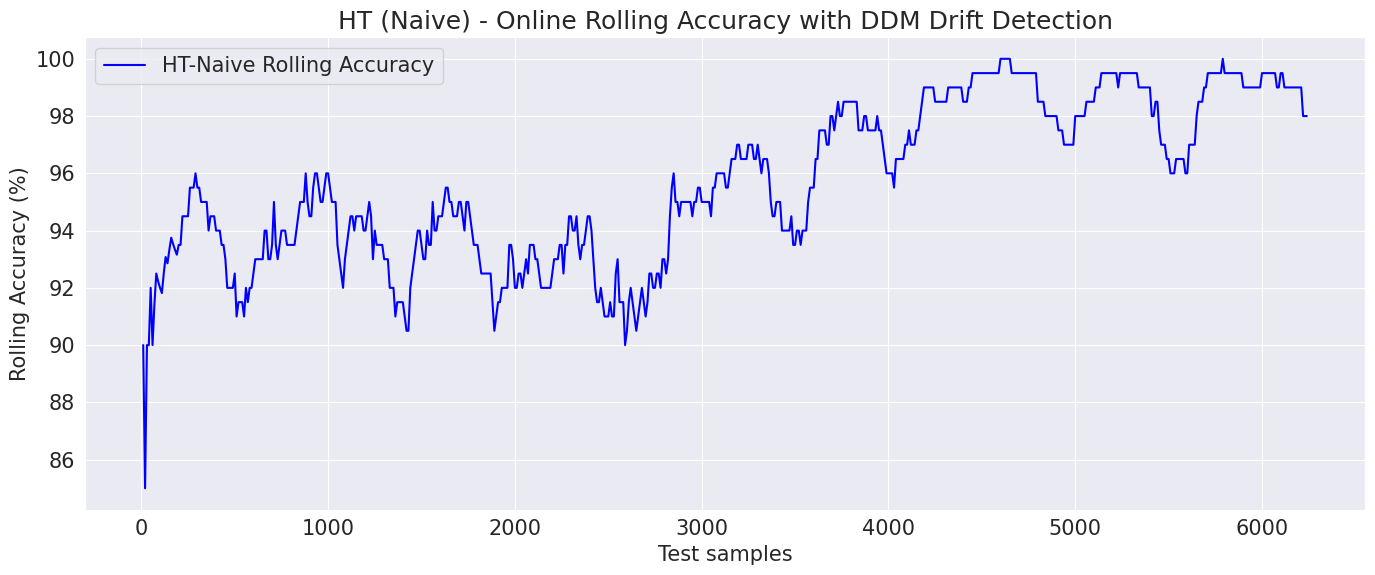

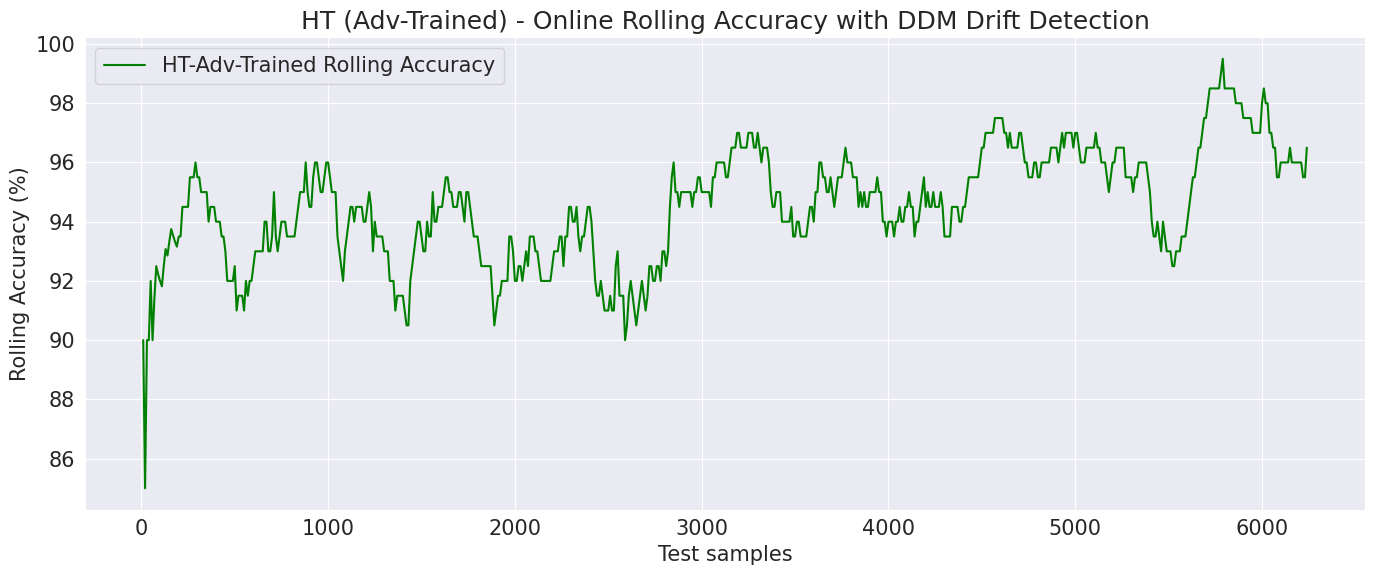

In [30]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='DDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for HT (NAIVE) --
model_ht_naive = tree.HoeffdingTreeClassifier()
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_ht_naive, X_test, y_test, drift_type='DDM', adv=False, label="HT-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="HT-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Naive) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for HT (ADV-TRAINED) --
model_ht_adv = tree.HoeffdingTreeClassifier()
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_ht_adv, X_test, y_test, drift_type='DDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="HT-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="HT-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Adv-Trained) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ADMIN

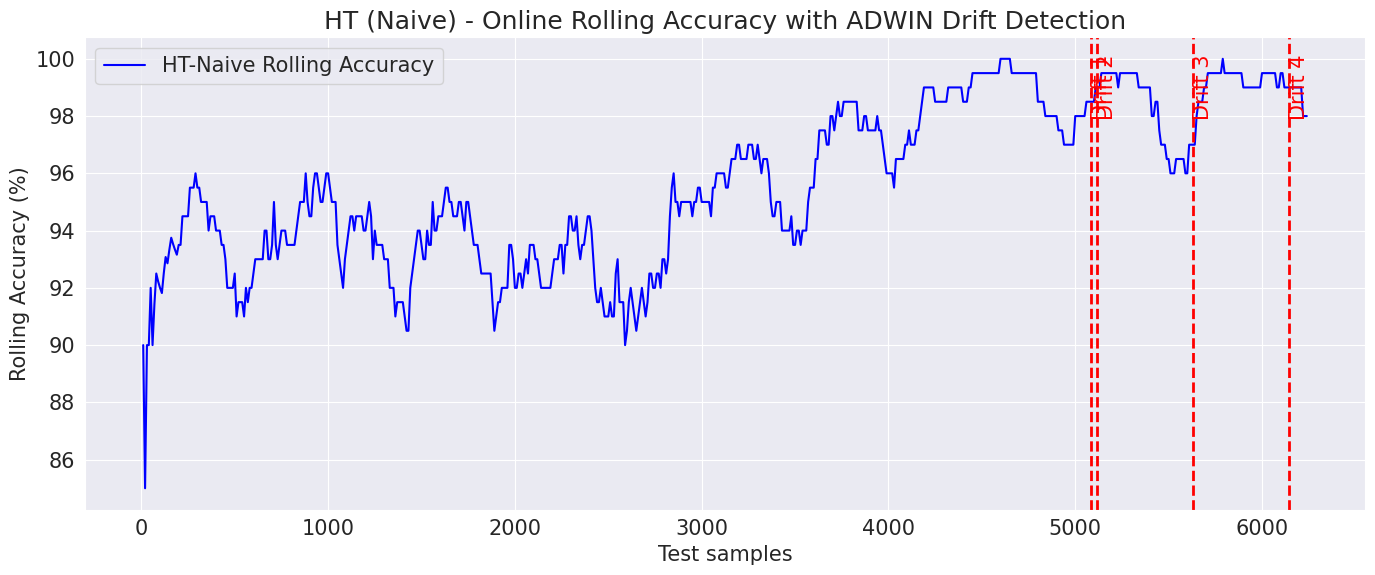

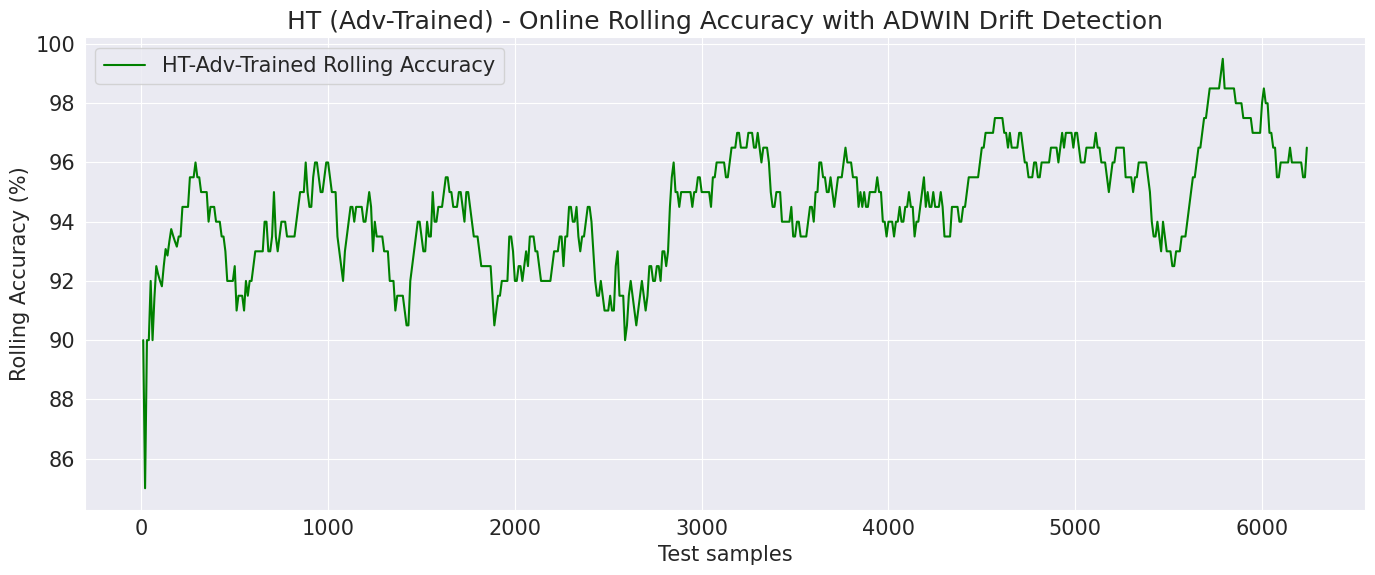

In [33]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='ADWIN',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for HT (NAIVE) --
model_ht_naive = tree.HoeffdingTreeClassifier()
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_ht_naive, X_test, y_test, drift_type='ADWIN', adv=False, label="HT-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="HT-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Naive) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for HT (ADV-TRAINED) --
model_ht_adv = tree.HoeffdingTreeClassifier()
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_ht_adv, X_test, y_test, drift_type='ADWIN',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="HT-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="HT-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Adv-Trained) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# EDDM

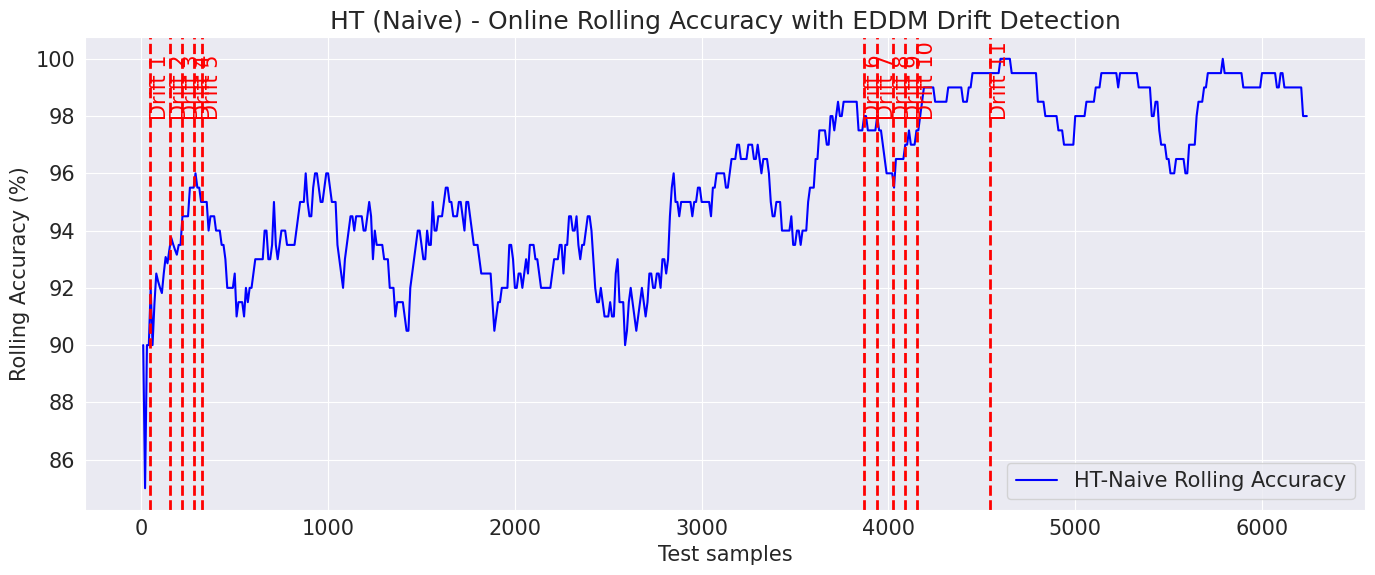

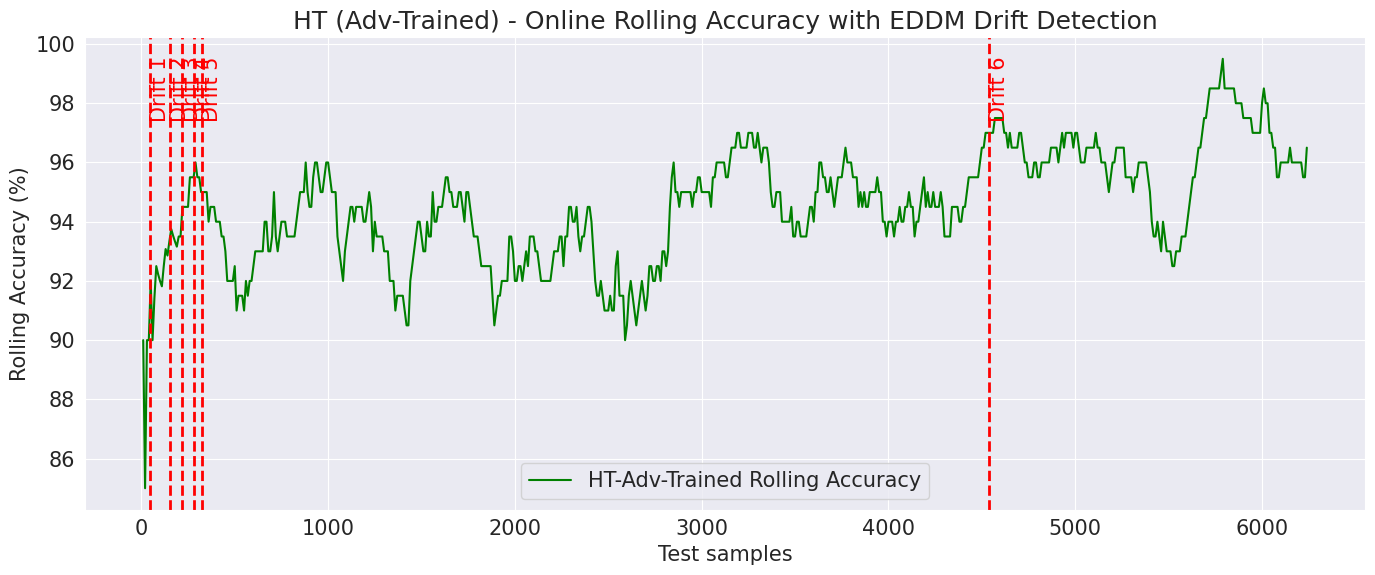

In [34]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='EDDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for HT (NAIVE) --
model_ht_naive = tree.HoeffdingTreeClassifier()
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_ht_naive, X_test, y_test, drift_type='EDDM', adv=False, label="HT-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="HT-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Naive) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for HT (ADV-TRAINED) --
model_ht_adv = tree.HoeffdingTreeClassifier()
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_ht_adv, X_test, y_test, drift_type='EDDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="HT-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="HT-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("HT (Adv-Trained) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Leveraging Bagging (LB) Model - Compact Option


==== Hoeffding Tree NAIVE Model Metrics ====
Accuracy:  98.143%
Precision: 98.716%
Recall:    99.32%
F1-score:  99.017%



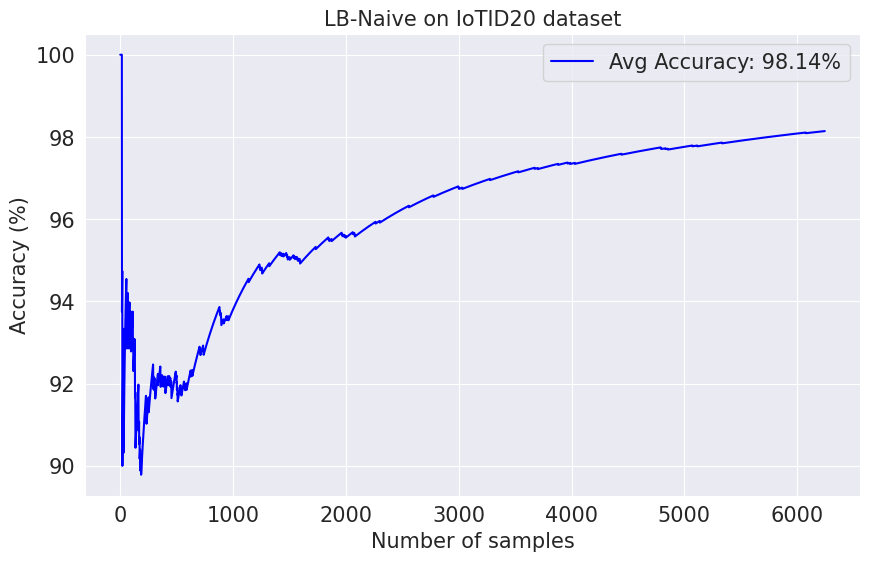


==== Hoeffding Tree ADVERSARIALLY-TRAINED Model Metrics ====
Accuracy:  98.591%
Precision: 98.772%
Recall:    99.745%
F1-score:  99.256%



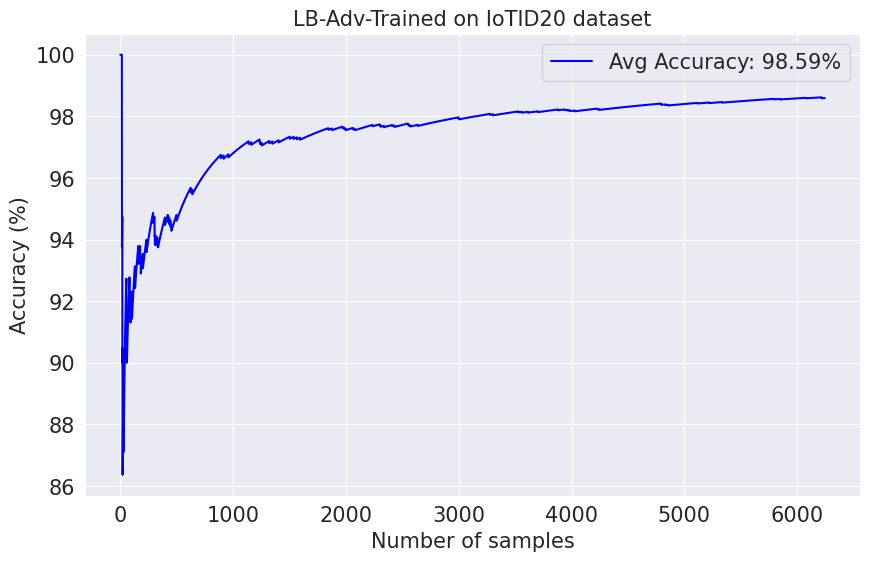

==== Cost-aware Adversarial Test: LEVERAGING BAGGING (NAIVE) ====
Cost budget=0.00: Clean acc=0.9958, Adv acc=0.9958
Cost budget=0.05: Clean acc=0.9958, Adv acc=0.9958
Cost budget=0.10: Clean acc=0.9958, Adv acc=0.8343
Cost budget=0.20: Clean acc=0.9958, Adv acc=0.8343
Cost budget=0.40: Clean acc=0.9958, Adv acc=0.8343
Cost budget=0.80: Clean acc=0.9958, Adv acc=0.8343
Cost budget=1.00: Clean acc=0.9958, Adv acc=0.8343

==== Cost-aware Adversarial Test: LEVERAGING BAGGING (ADV-TRAINED) ====
Cost budget=0.00: Clean acc=0.9926, Adv acc=0.9926
Cost budget=0.05: Clean acc=0.9926, Adv acc=0.9926
Cost budget=0.10: Clean acc=0.9926, Adv acc=0.9848
Cost budget=0.20: Clean acc=0.9926, Adv acc=0.9848
Cost budget=0.40: Clean acc=0.9926, Adv acc=0.9848
Cost budget=0.80: Clean acc=0.9926, Adv acc=0.9848
Cost budget=1.00: Clean acc=0.9926, Adv acc=0.9848



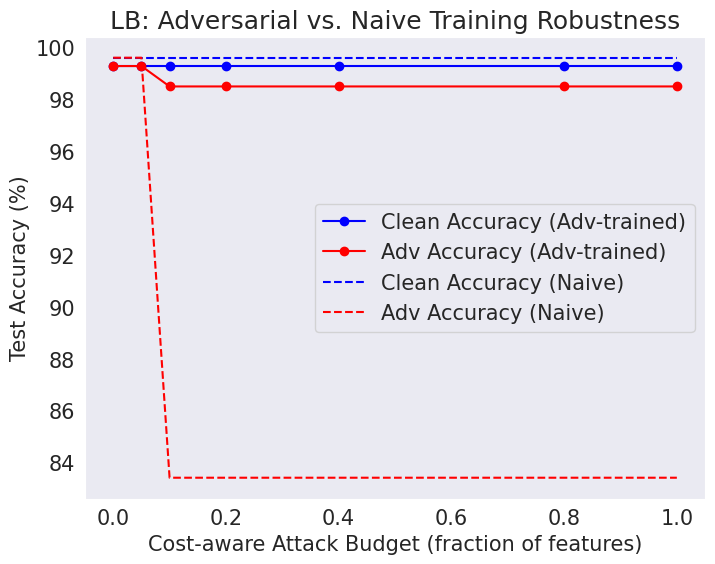

In [12]:
from river import ensemble, tree
import numpy as np

#----- Train NAIVE LB model -----
model2_naive = ensemble.LeveragingBaggingClassifier(
    model=tree.HoeffdingTreeClassifier(), n_models=3
)
t2_naive, m2_naive, accuracy, precision, recall, f1 = adaptive_learning(
    model2_naive, X_train, y_train, X_test, y_test
)
acc_fig(t2_naive, m2_naive, "LB-Naive")

#----- Train ADVERSARIALLY-TRAINED LB model -----
model2_adv = ensemble.LeveragingBaggingClassifier(
    model=tree.HoeffdingTreeClassifier(), n_models=3
)
t2_adv, m2_adv, accuracy_adv, precision_adv, recall_adv, f1_adv = adaptive_learning_adv(
    model2_adv, X_train, y_train, X_test, y_test,
    feature_costs, cost_budget, feature_ranges
)
acc_fig(t2_adv, m2_adv, "LB-Adv-Trained")

#----- Evaluate robustness under attack -----
def eval_under_attack(model, budgets, feature_costs, feature_ranges):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict_xi)
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model2_naive, budgets, feature_costs, feature_ranges)
results_adv = eval_under_attack(model2_adv, budgets, feature_costs, feature_ranges)

#------ Print with headings ------
print("==== Cost-aware Adversarial Test: LEVERAGING BAGGING (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=============================================================\n")

print("==== Cost-aware Adversarial Test: LEVERAGING BAGGING (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("===================================================================\n")

#------ Plot both ------
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('LB: Adversarial vs. Naive Training Robustness')
plt.legend()
plt.grid()
plt.show()

# LB Model with Resource Metrics Alone

In [13]:
from river import ensemble, tree, stream
from memory_profiler import memory_usage
import time

# --- NAIVE LB TRAINING PROFILED ---
model2_naive = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)

def train_naive_lb():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model2_naive.learn_one(dict(xi1), yi1)

t0 = time.perf_counter()
peak_mem_train_naive = memory_usage((train_naive_lb,), max_usage=True, retval=False)
train_wall_naive = time.perf_counter() - t0
print(f"[NAIVE-LB] Training wall time (s): {train_wall_naive:.4f} | Peak mem.: {peak_mem_train_naive:.2f} MB")

# --- NAIVE LB PREDICTION PROFILED ---
def pred_naive_lb():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model2_naive.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_naive = memory_usage((pred_naive_lb,), max_usage=True, retval=True)
pred_wall_naive = time.perf_counter() - t0
peak_mem_pred_naive = mem_pred_naive[0]
yt, yp = mem_pred_naive[1]
pred_times_naive = pred_wall_naive / len(yt) if len(yt) > 0 else float('nan')
print(f"[NAIVE-LB] Prediction wall time (s): {pred_wall_naive:.4f} | Peak mem.: {peak_mem_pred_naive:.2f} MB")
print(f"[NAIVE-LB] Avg prediction time/sample (ms): {pred_times_naive*1000:.4f}")

# --- ADV LB TRAINING PROFILED ---
model2_adv = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
def train_adv_lb():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model2_adv.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(
            dict(xi1), yi1, model2_adv, feature_costs, cost_budget, feature_ranges
        )
        model2_adv.learn_one(x_adv, yi1)

t0 = time.perf_counter()
peak_mem_train_adv = memory_usage((train_adv_lb,), max_usage=True, retval=False)
train_wall_adv = time.perf_counter() - t0
print(f"[ADV-TRAINED-LB] Training wall time (s): {train_wall_adv:.4f} | Peak mem.: {peak_mem_train_adv:.2f} MB")

# --- ADV LB PREDICTION PROFILED ---
def pred_adv_lb():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model2_adv.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_adv = memory_usage((pred_adv_lb,), max_usage=True, retval=True)
pred_wall_adv = time.perf_counter() - t0
peak_mem_pred_adv = mem_pred_adv[0]
yt_adv, yp_adv = mem_pred_adv[1]
pred_times_adv = pred_wall_adv / len(yt_adv) if len(yt_adv) > 0 else float('nan')
print(f"[ADV-TRAINED-LB] Prediction wall time (s): {pred_wall_adv:.4f} | Peak mem.: {peak_mem_pred_adv:.2f} MB")
print(f"[ADV-TRAINED-LB] Avg prediction time/sample (ms): {pred_times_adv*1000:.4f}")

# --- SUMMARY ---
print("\n==== Timing & Peak Memory Summary for Leveraging Bagging Model ====")
print(f"Train time (s):         Naive={train_wall_naive:.3f} | Adv-trained={train_wall_adv:.3f}")
print(f"Train peak mem (MB):    Naive={peak_mem_train_naive:.2f} | Adv-trained={peak_mem_train_adv:.2f}")
print(f"Pred time (s):          Naive={pred_wall_naive:.3f} | Adv-trained={pred_wall_adv:.3f}")
print(f"Pred peak mem (MB):     Naive={peak_mem_pred_naive:.2f} | Adv-trained={peak_mem_pred_adv:.2f}")
print(f"Avg pred/sample (ms):   Naive={pred_times_naive*1000:.3f} | Adv-trained={pred_times_adv*1000:.3f}")
print("=====================================\n")

[NAIVE-LB] Training wall time (s): 0.1072 | Peak mem.: 393.52 MB
[NAIVE-LB] Prediction wall time (s): 0.3925 | Peak mem.: 393.52 MB
[NAIVE-LB] Avg prediction time/sample (ms): 0.0628
[ADV-TRAINED-LB] Training wall time (s): 0.0950 | Peak mem.: 393.52 MB
[ADV-TRAINED-LB] Prediction wall time (s): 0.3909 | Peak mem.: 393.52 MB
[ADV-TRAINED-LB] Avg prediction time/sample (ms): 0.0626

==== Timing & Peak Memory Summary for Leveraging Bagging Model ====
Train time (s):         Naive=0.107 | Adv-trained=0.095
Train peak mem (MB):    Naive=393.52 | Adv-trained=393.52
Pred time (s):          Naive=0.393 | Adv-trained=0.391
Pred peak mem (MB):     Naive=393.52 | Adv-trained=393.52
Avg pred/sample (ms):   Naive=0.063 | Adv-trained=0.063



# LB Model with Drift Detection

DDM

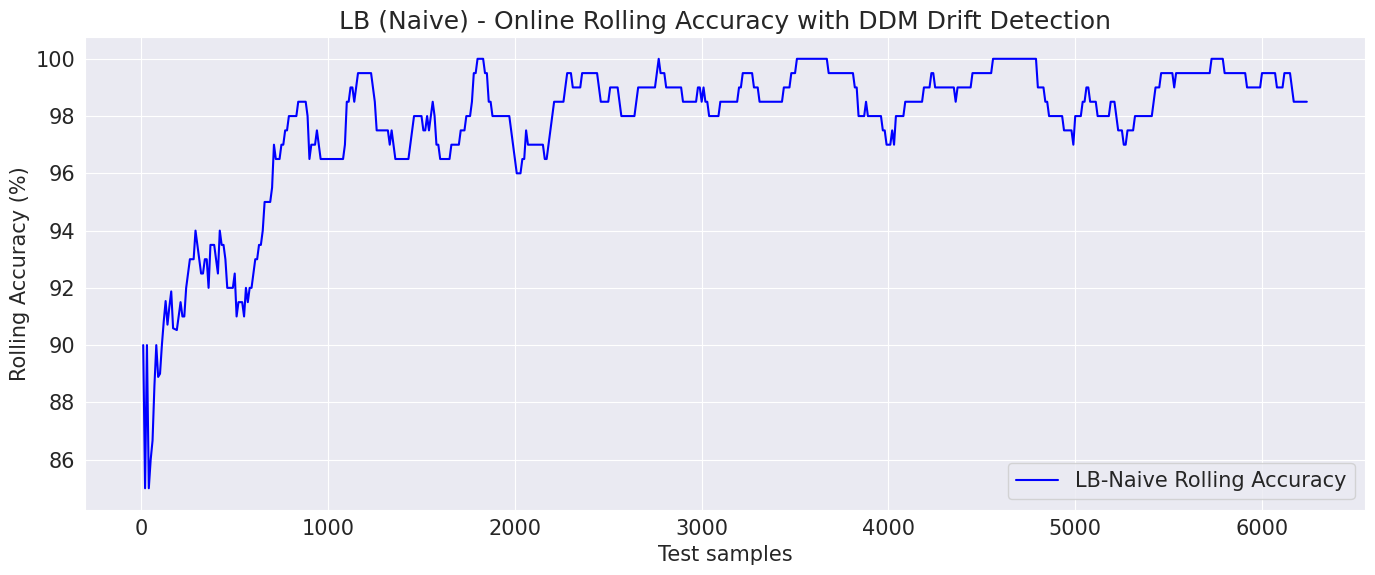

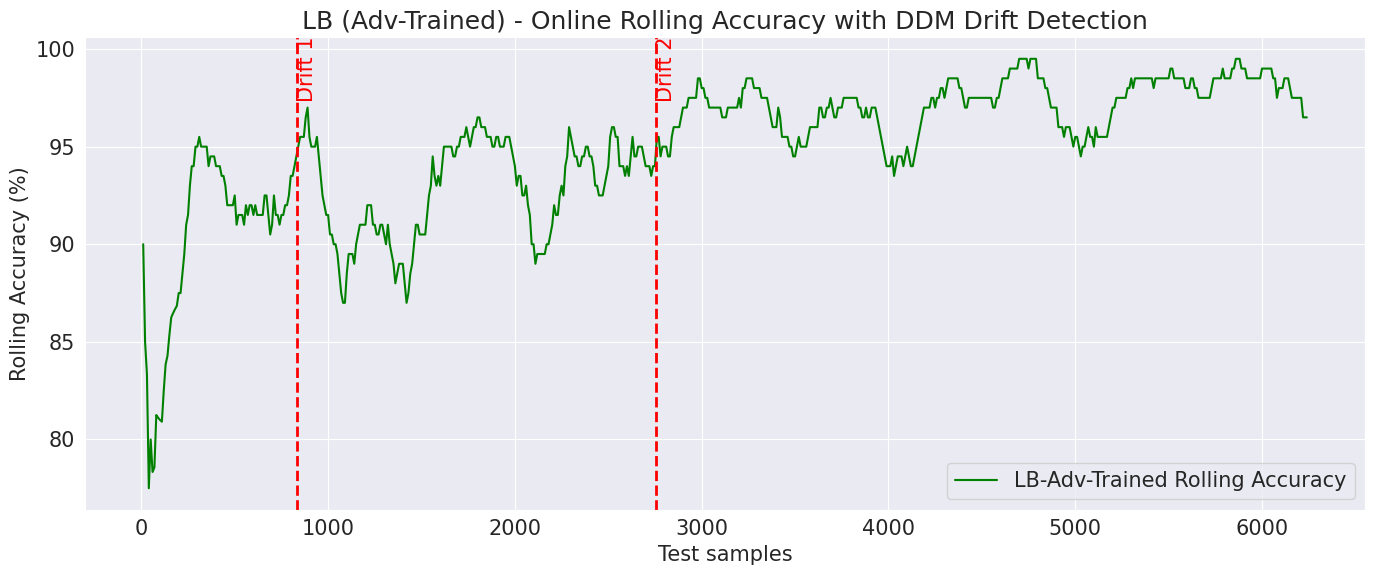

In [24]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='DDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for LB (NAIVE) --
model_lb_naive = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_lb_naive, X_test, y_test, drift_type='DDM', adv=False, label="LB-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="LB-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Naive) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for LB (ADV-TRAINED) --
model_lb_adv = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_lb_adv, X_test, y_test, drift_type='DDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="LB-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="LB-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Adv-Trained) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

ADWIN

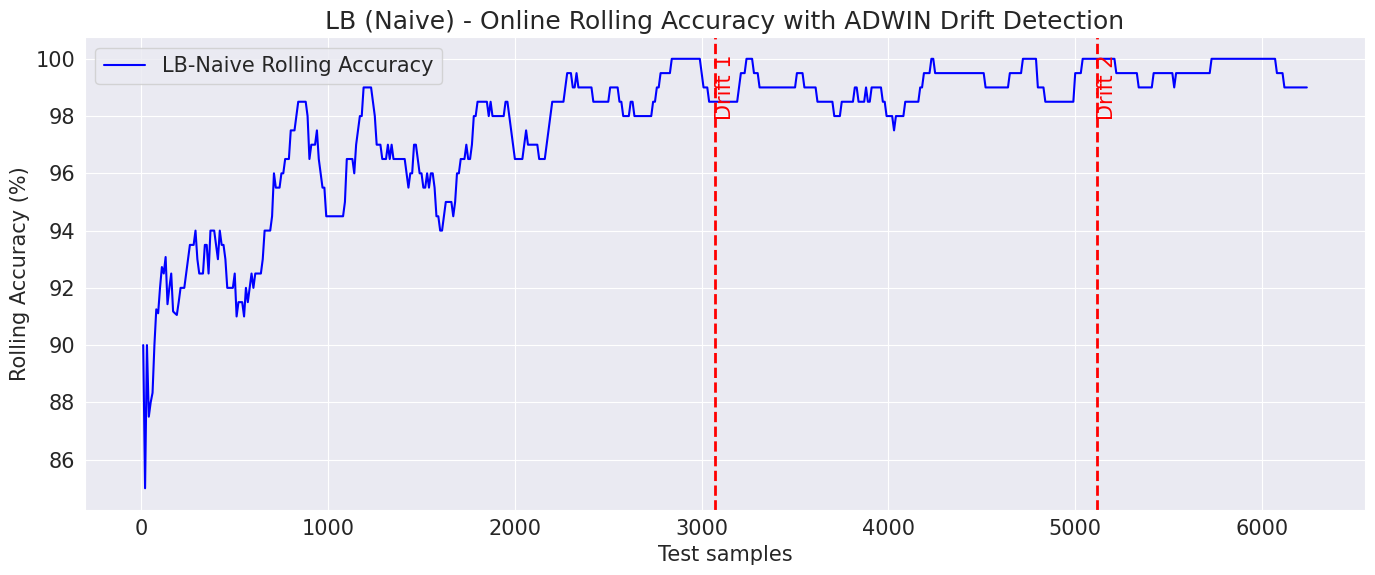

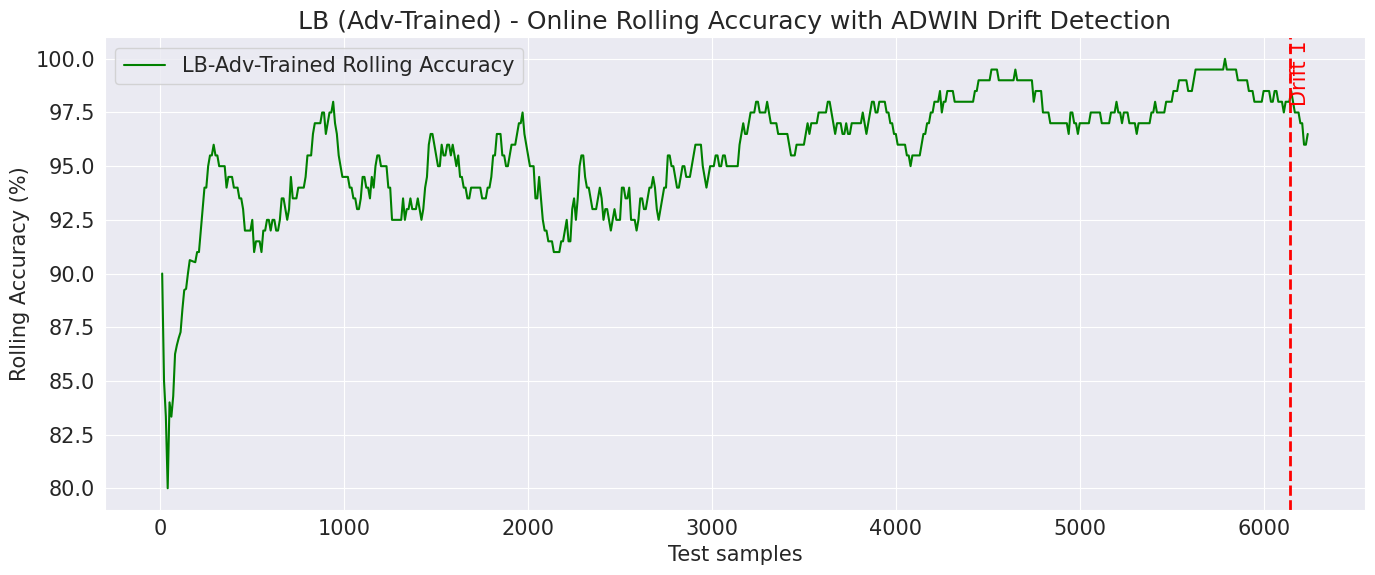

In [26]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='ADWIN',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for LB (NAIVE) --
model_lb_naive = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_lb_naive, X_test, y_test, drift_type='ADWIN', adv=False, label="LB-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="LB-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Naive) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for LB (ADV-TRAINED) --
model_lb_adv = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_lb_adv, X_test, y_test, drift_type='ADWIN',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="LB-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="LB-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Adv-Trained) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# EDDM

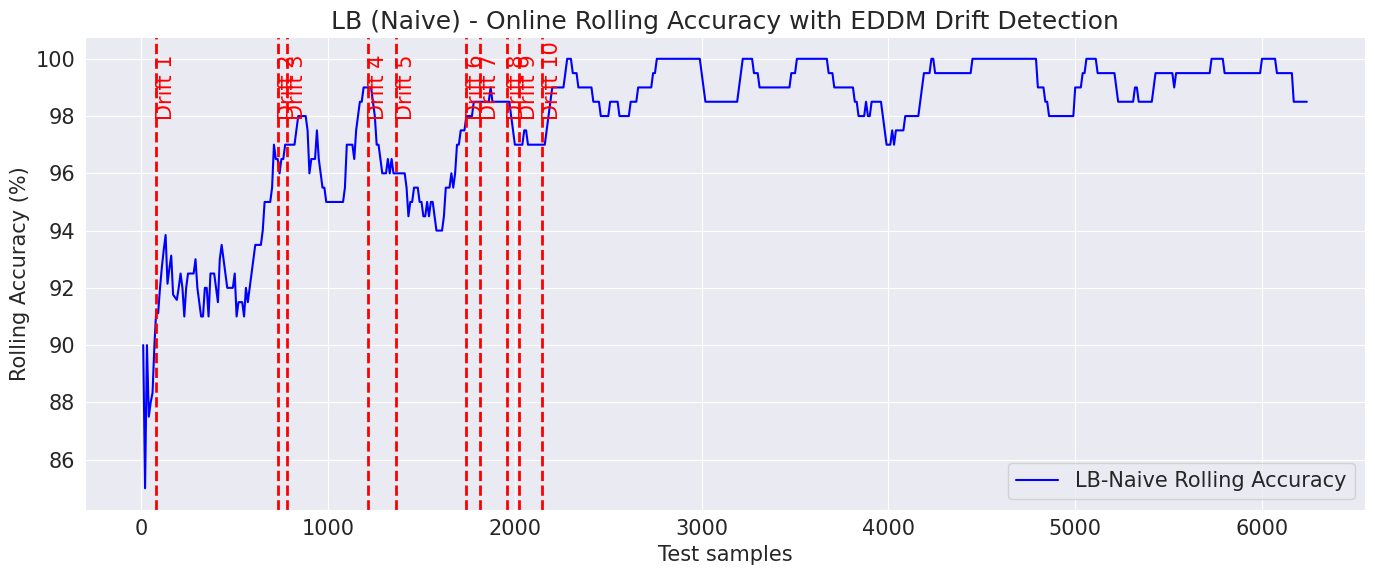

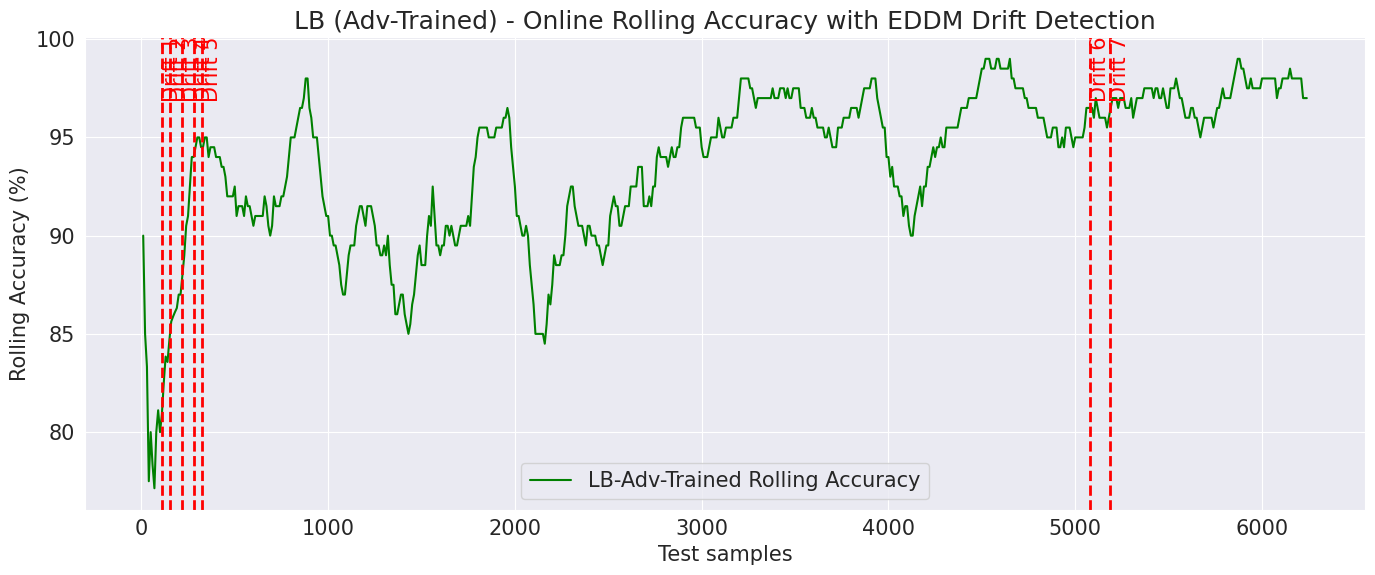

In [27]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble, tree

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='EDDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for LB (NAIVE) --
model_lb_naive = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_lb_naive, X_test, y_test, drift_type='EDDM', adv=False, label="LB-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="LB-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Naive) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for LB (ADV-TRAINED) --
model_lb_adv = ensemble.LeveragingBaggingClassifier(model=tree.HoeffdingTreeClassifier(), n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_lb_adv, X_test, y_test, drift_type='EDDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="LB-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="LB-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("LB (Adv-Trained) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

#  Streaming Random Patches (SRP) Model - Compact Option


==== Hoeffding Tree NAIVE Model Metrics ====
Accuracy:  98.943%
Precision: 99.105%
Recall:    99.779%
F1-score:  99.441%



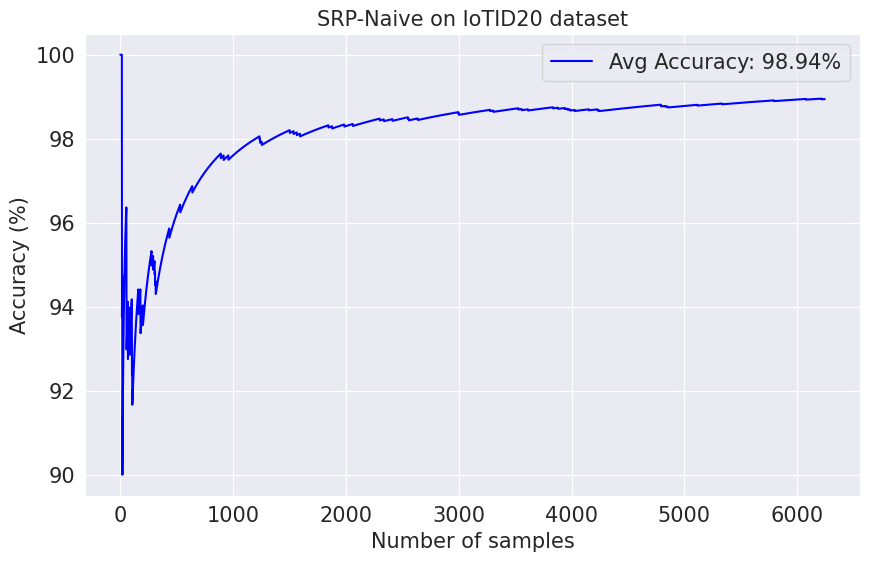


==== Hoeffding Tree ADVERSARIALLY-TRAINED Model Metrics ====
Accuracy:  98.895%
Precision: 99.055%
Recall:    99.779%
F1-score:  99.416%



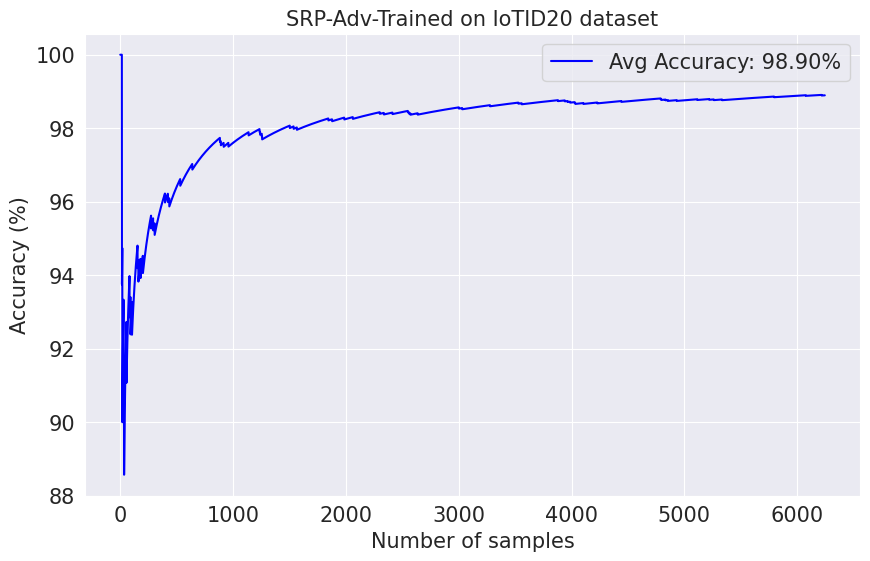

==== Cost-aware Adversarial Test: SRP (NAIVE) ====
Cost budget=0.00: Clean acc=0.9939, Adv acc=0.9939
Cost budget=0.05: Clean acc=0.9939, Adv acc=0.9939
Cost budget=0.10: Clean acc=0.9939, Adv acc=0.9145
Cost budget=0.20: Clean acc=0.9939, Adv acc=0.9145
Cost budget=0.40: Clean acc=0.9939, Adv acc=0.9145
Cost budget=0.80: Clean acc=0.9939, Adv acc=0.9145
Cost budget=1.00: Clean acc=0.9939, Adv acc=0.9145

==== Cost-aware Adversarial Test: SRP (ADV-TRAINED) ====
Cost budget=0.00: Clean acc=0.9934, Adv acc=0.9934
Cost budget=0.05: Clean acc=0.9934, Adv acc=0.9934
Cost budget=0.10: Clean acc=0.9934, Adv acc=0.9848
Cost budget=0.20: Clean acc=0.9934, Adv acc=0.9848
Cost budget=0.40: Clean acc=0.9934, Adv acc=0.9848
Cost budget=0.80: Clean acc=0.9934, Adv acc=0.9848
Cost budget=1.00: Clean acc=0.9934, Adv acc=0.9848



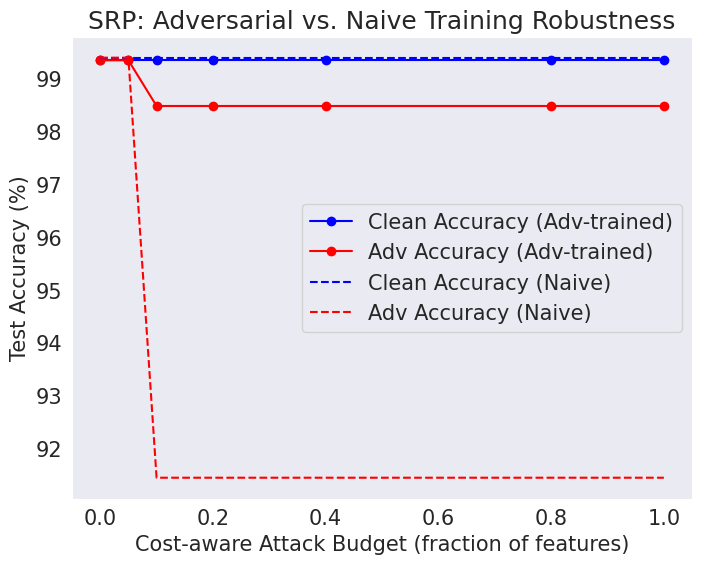

In [14]:
from river import ensemble, tree
import numpy as np
import matplotlib.pyplot as plt

# 1. NAIVE SRP model (no adversarial training)
model4_naive = ensemble.SRPClassifier(n_models=3)
t4_naive, m4_naive, accuracy_naive, precision_naive, recall_naive, f1_naive = adaptive_learning(
    model4_naive, X_train, y_train, X_test, y_test
)
acc_fig(t4_naive, m4_naive, "SRP-Naive")

# 2. ADVERSARIALLY-TRAINED SRP model
model4_adv = ensemble.SRPClassifier(n_models=3)
t4_adv, m4_adv, accuracy_adv, precision_adv, recall_adv, f1_adv = adaptive_learning_adv(
    model4_adv, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges
)
acc_fig(t4_adv, m4_adv, "SRP-Adv-Trained")

# 3. DEFINE ROBUSTNESS EVALUATION FUNCTION (if not already defined)
def eval_under_attack(model, budgets, feature_costs, feature_ranges):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict_xi)
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model4_naive, budgets, feature_costs, feature_ranges)
results_adv = eval_under_attack(model4_adv, budgets, feature_costs, feature_ranges)

# 4. PRINT HEADINGED RESULTS
print("==== Cost-aware Adversarial Test: SRP (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("==================================================\n")

print("==== Cost-aware Adversarial Test: SRP (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=======================================================\n")

# 5. PLOT BOTH
plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('SRP: Adversarial vs. Naive Training Robustness')
plt.legend()
plt.grid()
plt.show()

# SRP with Time Metrics Alone

In [15]:
from memory_profiler import memory_usage
import time

# ---- NAIVE TRAINING PROFILED ----
model4_naive = ensemble.SRPClassifier(n_models=3)

def train_naive():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model4_naive.learn_one(dict(xi1), yi1)

t0 = time.perf_counter()
peak_mem_train_naive = memory_usage((train_naive,), max_usage=True, retval=False)
train_wall_naive = time.perf_counter() - t0
print(f"[NAIVE] Training wall time (s): {train_wall_naive:.4f} | Peak mem.: {peak_mem_train_naive:.2f} MB")

# ---- NAIVE PREDICTION PROFILED ----
def pred_naive():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model4_naive.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_naive = memory_usage((pred_naive,), max_usage=True, retval=True)
pred_wall_naive = time.perf_counter() - t0
peak_mem_pred_naive = mem_pred_naive[0]
yt, yp = mem_pred_naive[1]
pred_times_naive = pred_wall_naive / len(yt) if len(yt) > 0 else float('nan')
print(f"[NAIVE] Prediction wall time (s): {pred_wall_naive:.4f} | Peak mem.: {peak_mem_pred_naive:.2f} MB")
print(f"[NAIVE] Avg prediction/sample (ms): {pred_times_naive*1000:.4f}")

# ---- ADV TRAINED TRAINING PROFILED ----
model4_adv = ensemble.SRPClassifier(n_models=3)
def train_adv():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model4_adv.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(
            dict(xi1), yi1, model4_adv, feature_costs, cost_budget, feature_ranges
        )
        model4_adv.learn_one(x_adv, yi1)

t0 = time.perf_counter()
peak_mem_train_adv = memory_usage((train_adv,), max_usage=True, retval=False)
train_wall_adv = time.perf_counter() - t0
print(f"[ADV-TRAINED] Training wall time (s): {train_wall_adv:.4f} | Peak mem.: {peak_mem_train_adv:.2f} MB")

# ---- ADV TRAINED PREDICTION PROFILED ----
def pred_adv():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model4_adv.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_adv = memory_usage((pred_adv,), max_usage=True, retval=True)
pred_wall_adv = time.perf_counter() - t0
peak_mem_pred_adv = mem_pred_adv[0]
yt_adv, yp_adv = mem_pred_adv[1]
pred_times_adv = pred_wall_adv / len(yt_adv) if len(yt_adv) > 0 else float('nan')
print(f"[ADV-TRAINED] Prediction wall time (s): {pred_wall_adv:.4f} | Peak mem.: {peak_mem_pred_adv:.2f} MB")
print(f"[ADV-TRAINED] Avg prediction/sample (ms): {pred_times_adv*1000:.4f}")

# ---- Timing/Mem Summary for SRP ----
print("\n==== Timing & Peak Memory Summary for SRP Model ====")
print(f"Train time (s):      Naive={train_wall_naive:.3f} | Adv-trained={train_wall_adv:.3f}")
print(f"Train peak mem (MB): Naive={peak_mem_train_naive:.2f} | Adv-trained={peak_mem_train_adv:.2f}")
print(f"Pred time (s):       Naive={pred_wall_naive:.3f} | Adv-trained={pred_wall_adv:.3f}")
print(f"Pred peak mem (MB):  Naive={peak_mem_pred_naive:.2f} | Adv-trained={peak_mem_pred_adv:.2f}")
print(f"Avg pred/sample (ms):Naive={pred_times_naive*1000:.3f} | Adv-trained={pred_times_adv*1000:.3f}")
print("=====================================\n")

[NAIVE] Training wall time (s): 0.2089 | Peak mem.: 399.00 MB
[NAIVE] Prediction wall time (s): 0.6638 | Peak mem.: 399.00 MB
[NAIVE] Avg prediction/sample (ms): 0.1063
[ADV-TRAINED] Training wall time (s): 0.1943 | Peak mem.: 399.00 MB
[ADV-TRAINED] Prediction wall time (s): 0.4558 | Peak mem.: 399.00 MB
[ADV-TRAINED] Avg prediction/sample (ms): 0.0730

==== Timing & Peak Memory Summary for SRP Model ====
Train time (s):      Naive=0.209 | Adv-trained=0.194
Train peak mem (MB): Naive=399.00 | Adv-trained=399.00
Pred time (s):       Naive=0.664 | Adv-trained=0.456
Pred peak mem (MB):  Naive=399.00 | Adv-trained=399.00
Avg pred/sample (ms):Naive=0.106 | Adv-trained=0.073



# SRP with Drift Detection

# SRP and Drift Detection with DDM

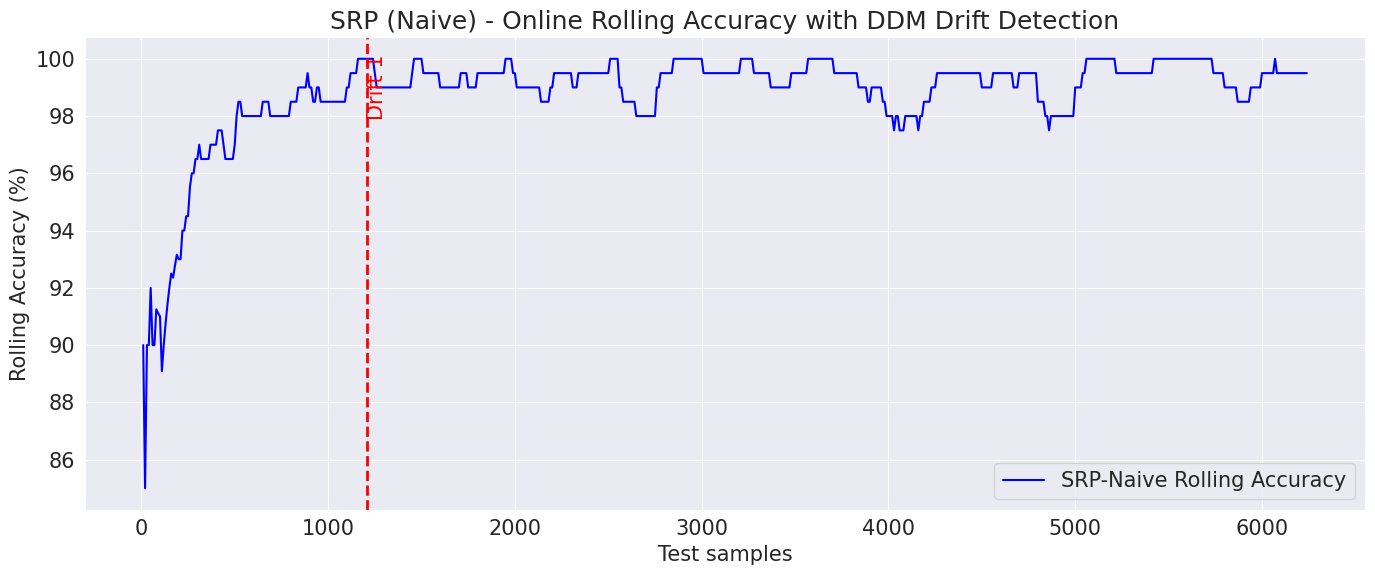

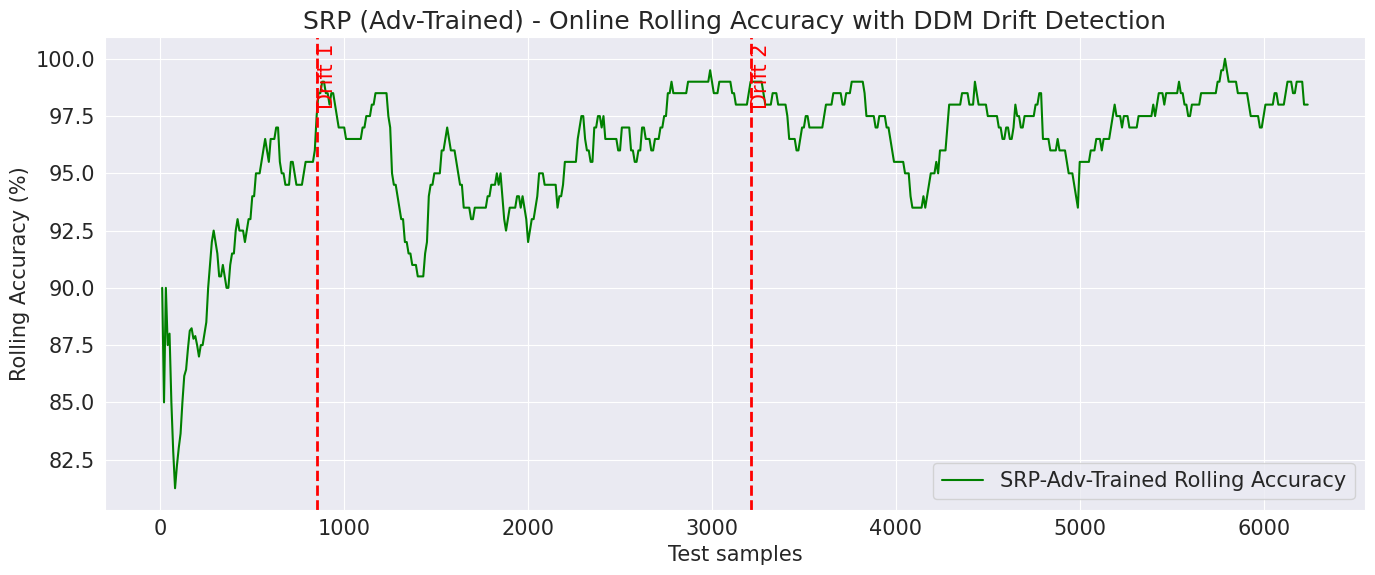

In [18]:
!pip install river
import numpy as np

from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='DDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for SRP (NAIVE) --
model4_naive = ensemble.SRPClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model4_naive, X_test, y_test, drift_type='DDM', adv=False, label="SRP-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="SRP-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Naive) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for SRP (ADV-TRAINED) --
model4_adv = ensemble.SRPClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model4_adv, X_test, y_test, drift_type='DDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="SRP-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="SRP-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Adv-Trained) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# SRP and Drift Detection with ADWIN

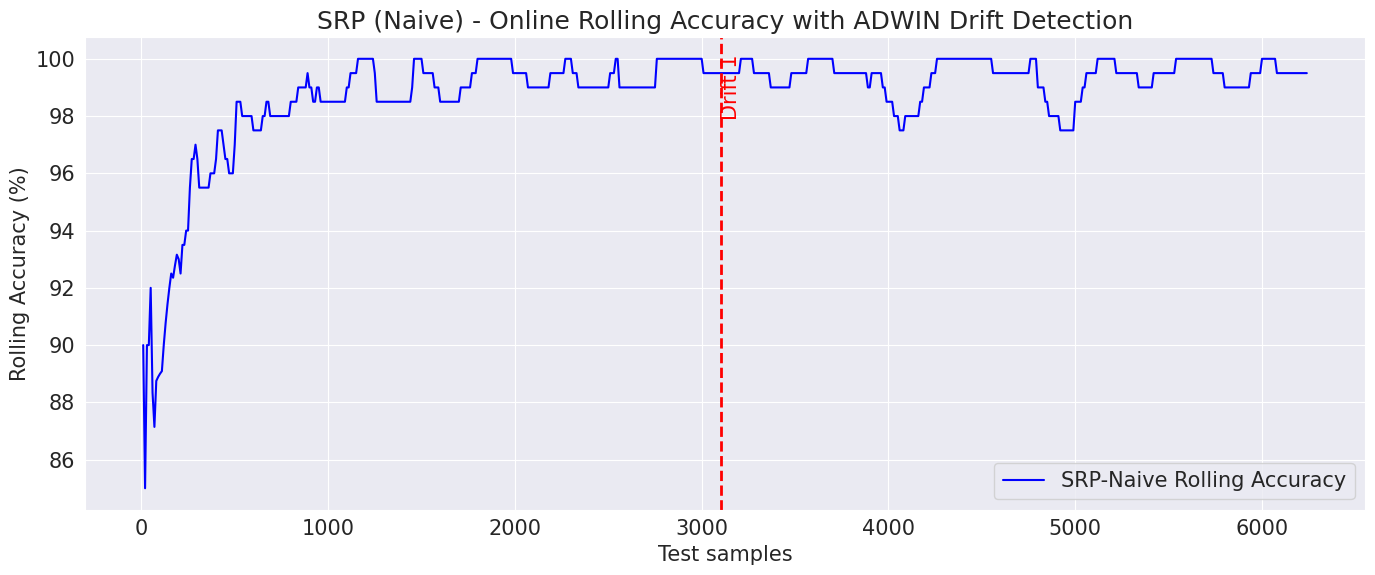

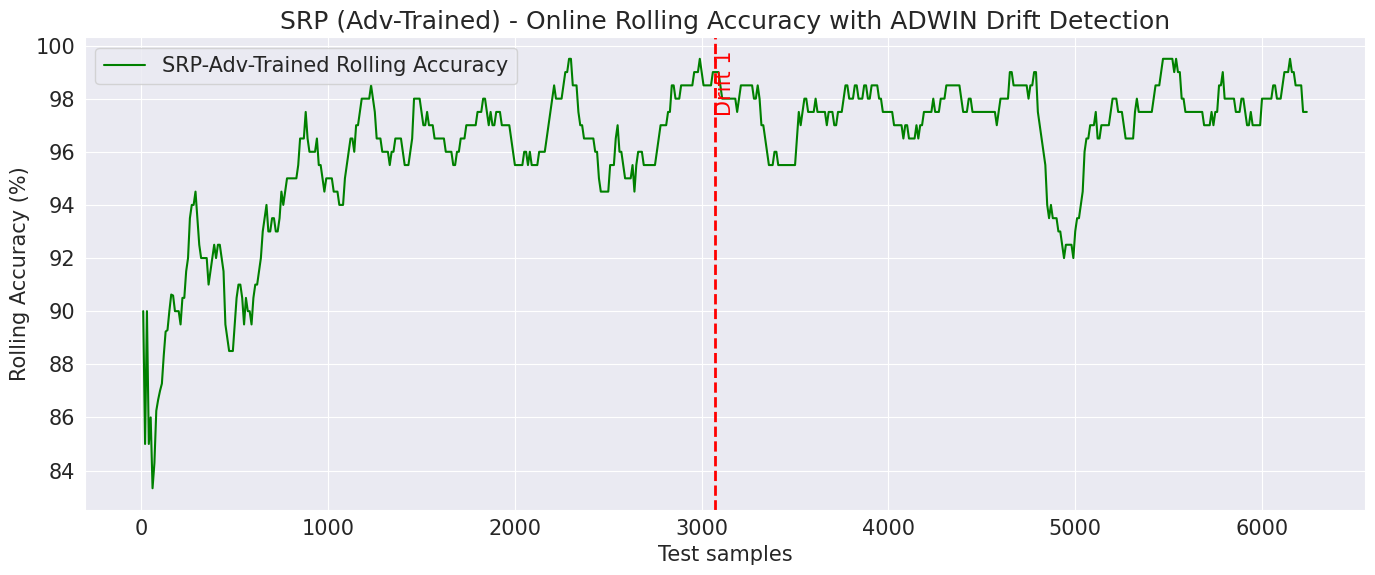

In [19]:
!pip install river
import numpy as np

from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='ADWIN',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for SRP (NAIVE) --
model4_naive = ensemble.SRPClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model4_naive, X_test, y_test, drift_type='ADWIN', adv=False, label="SRP-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="SRP-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Naive) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for SRP (ADV-TRAINED) --
model4_adv = ensemble.SRPClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model4_adv, X_test, y_test, drift_type='ADWIN',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="SRP-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="SRP-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Adv-Trained) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# SRP and Drift Detection with EDDM

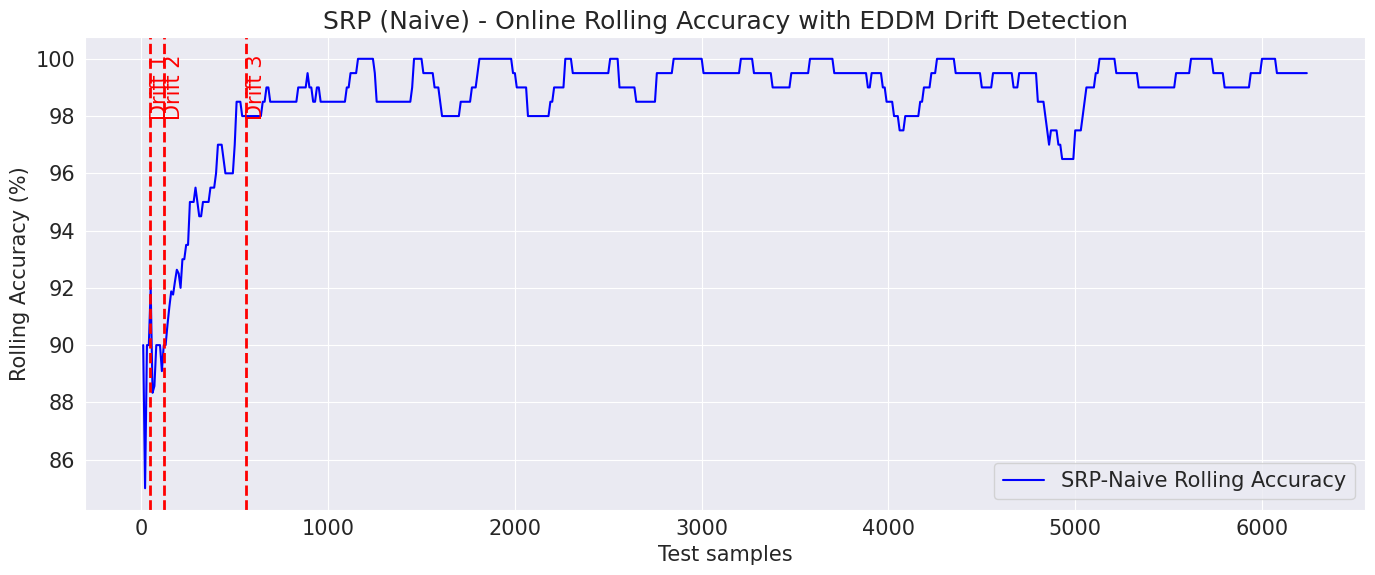

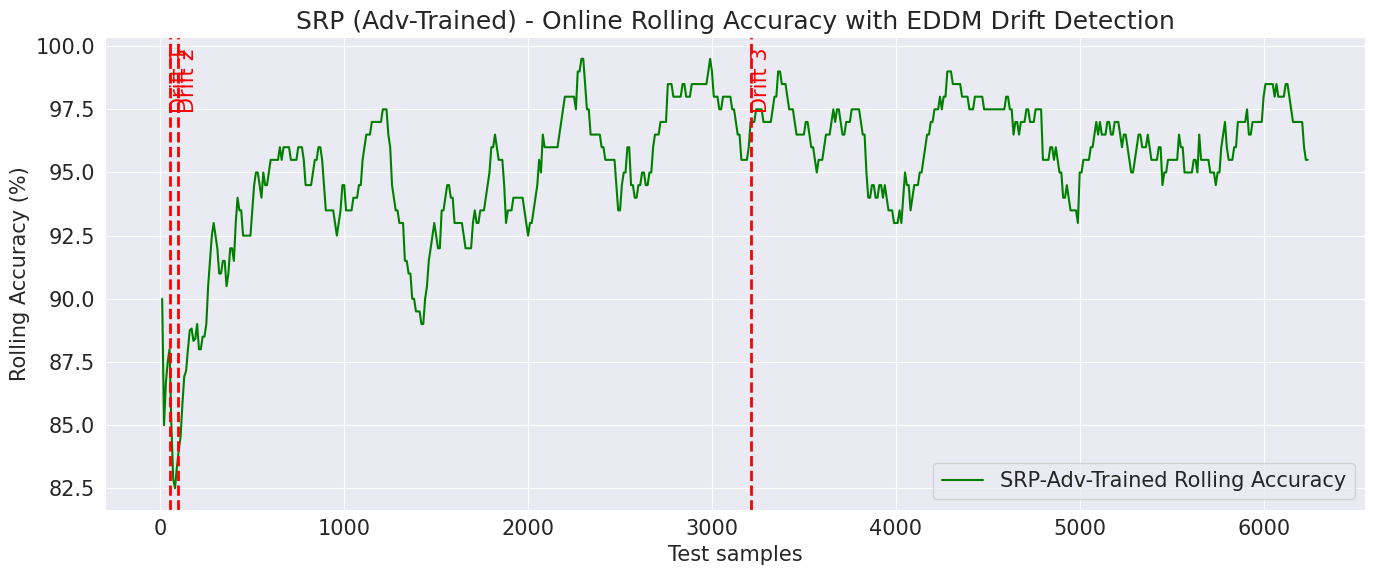

In [21]:
!pip install river
import numpy as np

from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='EDDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for SRP (NAIVE) --
model4_naive = ensemble.SRPClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model4_naive, X_test, y_test, drift_type='EDDM', adv=False, label="SRP-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="SRP-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Naive) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for SRP (ADV-TRAINED) --
model4_adv = ensemble.SRPClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model4_adv, X_test, y_test, drift_type='EDDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="SRP-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="SRP-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("SRP (Adv-Trained) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# SRP with Other Metrics - Has Peak Memory. PLEASE AVOID.

But takes a lot of time. More than 1 hour

# Hoeffding Adaptive Tree: The Compact Option


==== Hoeffding Tree NAIVE Model Metrics ====
Accuracy:  95.837%
Precision: 96.16%
Recall:    99.558%
F1-score:  97.829%



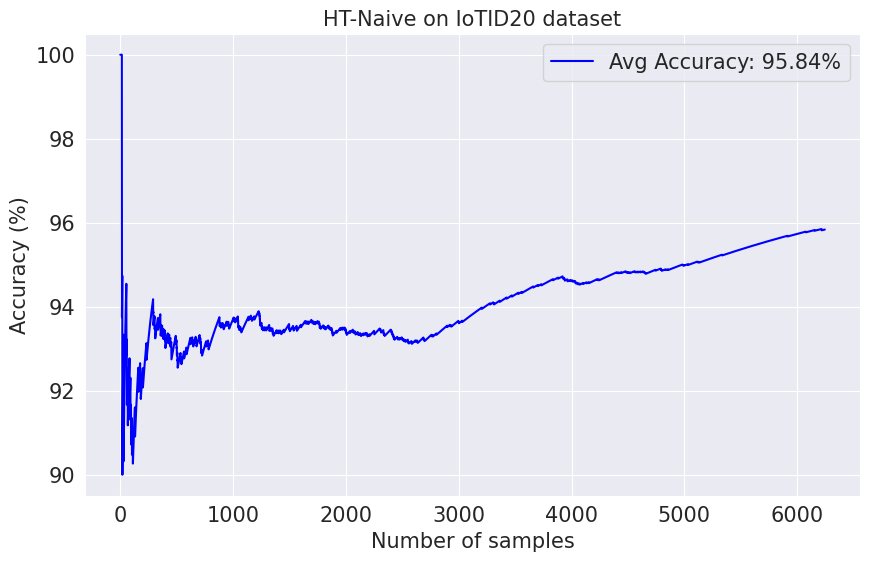


==== Hoeffding Tree ADVERSARIALLY-TRAINED Model Metrics ====
Accuracy:  96.83%
Precision: 97.226%
Recall:    99.473%
F1-score:  98.337%



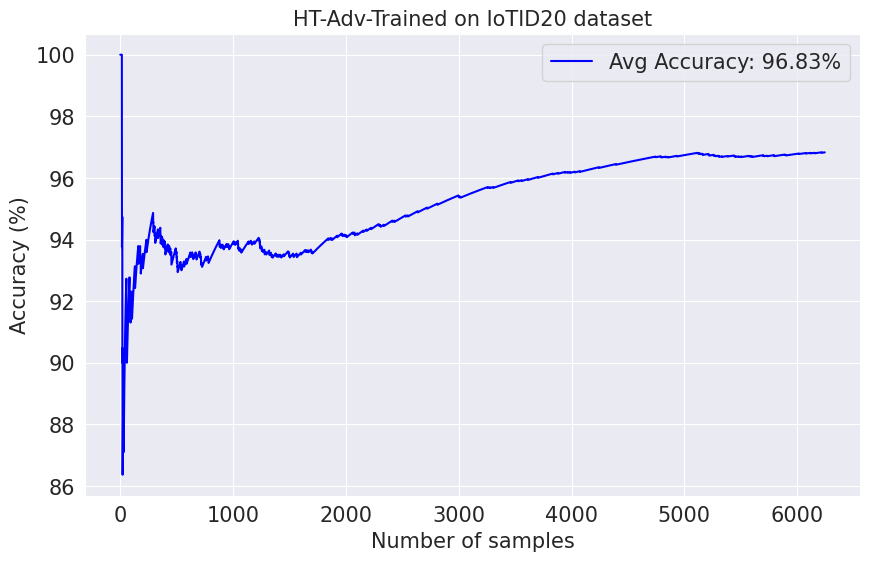

==== Cost-aware Adversarial Test: HOEFFDING ADAPTIVE TREE (NAIVE) ====
Cost budget=0.00: Clean acc=0.9880, Adv acc=0.9880
Cost budget=0.05: Clean acc=0.9880, Adv acc=0.9880
Cost budget=0.10: Clean acc=0.9880, Adv acc=0.9065
Cost budget=0.20: Clean acc=0.9880, Adv acc=0.9065
Cost budget=0.40: Clean acc=0.9880, Adv acc=0.9065
Cost budget=0.80: Clean acc=0.9880, Adv acc=0.9065
Cost budget=1.00: Clean acc=0.9880, Adv acc=0.9065

==== Cost-aware Adversarial Test: HOEFFDING ADAPTIVE TREE (ADV-TRAINED) ====
Cost budget=0.00: Clean acc=0.9859, Adv acc=0.9859
Cost budget=0.05: Clean acc=0.9859, Adv acc=0.9859
Cost budget=0.10: Clean acc=0.9859, Adv acc=0.9331
Cost budget=0.20: Clean acc=0.9859, Adv acc=0.9331
Cost budget=0.40: Clean acc=0.9859, Adv acc=0.9331
Cost budget=0.80: Clean acc=0.9859, Adv acc=0.9331
Cost budget=1.00: Clean acc=0.9859, Adv acc=0.9331



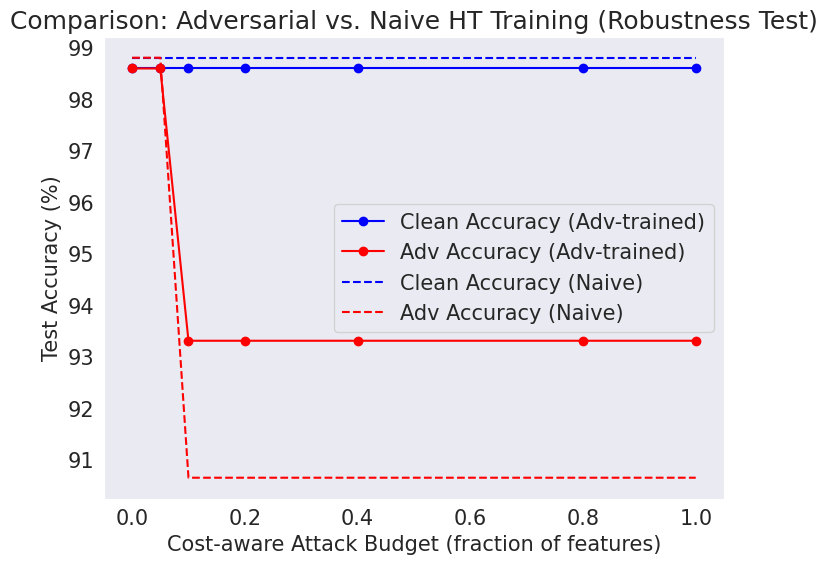

In [17]:
from river import tree, stream, metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6))
    sns.set_style("darkgrid")
    plt.clf()
    plt.plot(t, m, '-b', label='Avg Accuracy: %.2f%%' % (m[-1]))
    plt.legend(loc='best')
    plt.title(name+' on IoTID20 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.draw()
    plt.show()

# --- Standard training (naive model) ---
def adaptive_learning(model, X_train, y_train, X_test, y_test):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== Hoeffding Adaptive Tree NAIVE Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Adversarial training (adv-trained model) ---
def adaptive_learning_adv(model, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        x_adv = cost_aware_adversarial_example(dict(xi), yi, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== Hoeffding Adaptive Tree ADVERSARIALLY-TRAINED Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Train models ---
model1_naive = tree.HoeffdingAdaptiveTreeClassifier()
t_naive, m_naive, _, _, _, _ = adaptive_learning(model1_naive, X_train, y_train, X_test, y_test)
acc_fig(t_naive, m_naive, "HT-Naive")

model1_adv = tree.HoeffdingAdaptiveTreeClassifier()
t_adv, m_adv, _, _, _, _ = adaptive_learning_adv(model1_adv, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t_adv, m_adv, "HT-Adv-Trained")

# --- Evaluation under attack ---
def eval_under_attack(model, budgets, feature_costs, feature_ranges):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict_xi)
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model1_naive, budgets, feature_costs, feature_ranges)
results_adv = eval_under_attack(model1_adv, budgets, feature_costs, feature_ranges)

# ---- Print attack robustness with headings ---
print("==== Cost-aware Adversarial Test: HOEFFDING ADAPTIVE TREE (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=============================================================\n")

print("==== Cost-aware Adversarial Test: HOEFFDING ADAPTIVE TREE (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("===================================================================\n")

# --- Plot ---
plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('Comparison: Adversarial vs. Naive HT Training (Robustness Test)')
plt.legend()
plt.grid()
plt.show()

# Hoeffding Adaptive Tree with Time Metrics

In [18]:
from river import tree, stream
from memory_profiler import memory_usage
import time

# --- NAIVE HoeffdingAdaptiveTree TRAINING PROFILED ---
model5_naive = tree.HoeffdingAdaptiveTreeClassifier()

def train_naive_hat():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model5_naive.learn_one(dict(xi1), yi1)

t0 = time.perf_counter()
peak_mem_train_naive = memory_usage((train_naive_hat,), max_usage=True, retval=False)
train_wall_naive = time.perf_counter() - t0
print(f"[NAIVE-HAT] Training wall time (s): {train_wall_naive:.4f} | Peak mem.: {peak_mem_train_naive:.2f} MB")

# --- NAIVE HoeffdingAdaptiveTree PREDICTION PROFILED ---
def pred_naive_hat():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model5_naive.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_naive = memory_usage((pred_naive_hat,), max_usage=True, retval=True)
pred_wall_naive = time.perf_counter() - t0
peak_mem_pred_naive = mem_pred_naive[0]
yt, yp = mem_pred_naive[1]
pred_times_naive = pred_wall_naive / len(yt) if len(yt) > 0 else float('nan')
print(f"[NAIVE-HAT] Prediction wall time (s): {pred_wall_naive:.4f} | Peak mem.: {peak_mem_pred_naive:.2f} MB")
print(f"[NAIVE-HAT] Avg prediction time/sample (ms): {pred_times_naive*1000:.4f}")

# --- ADV HoeffdingAdaptiveTree TRAINING PROFILED ---
model5_adv = tree.HoeffdingAdaptiveTreeClassifier()
def train_adv_hat():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model5_adv.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(
            dict(xi1), yi1, model5_adv, feature_costs, cost_budget, feature_ranges
        )
        model5_adv.learn_one(x_adv, yi1)

t0 = time.perf_counter()
peak_mem_train_adv = memory_usage((train_adv_hat,), max_usage=True, retval=False)
train_wall_adv = time.perf_counter() - t0
print(f"[ADV-TRAINED-HAT] Training wall time (s): {train_wall_adv:.4f} | Peak mem.: {peak_mem_train_adv:.2f} MB")

# --- ADV HoeffdingAdaptiveTree PREDICTION PROFILED ---
def pred_adv_hat():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model5_adv.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_adv = memory_usage((pred_adv_hat,), max_usage=True, retval=True)
pred_wall_adv = time.perf_counter() - t0
peak_mem_pred_adv = mem_pred_adv[0]
yt_adv, yp_adv = mem_pred_adv[1]
pred_times_adv = pred_wall_adv / len(yt_adv) if len(yt_adv) > 0 else float('nan')
print(f"[ADV-TRAINED-HAT] Prediction wall time (s): {pred_wall_adv:.4f} | Peak mem.: {peak_mem_pred_adv:.2f} MB")
print(f"[ADV-TRAINED-HAT] Avg prediction time/sample (ms): {pred_times_adv*1000:.4f}")

# --- SUMMARY ---
print("\n==== Timing & Peak Memory Summary for Hoeffding Adaptive Tree Model ====")
print(f"Train time (s):         Naive={train_wall_naive:.3f} | Adv-trained={train_wall_adv:.3f}")
print(f"Train peak mem (MB):    Naive={peak_mem_train_naive:.2f} | Adv-trained={peak_mem_train_adv:.2f}")
print(f"Pred time (s):          Naive={pred_wall_naive:.3f} | Adv-trained={pred_wall_adv:.3f}")
print(f"Pred peak mem (MB):     Naive={peak_mem_pred_naive:.2f} | Adv-trained={peak_mem_pred_adv:.2f}")
print(f"Avg pred/sample (ms):   Naive={pred_times_naive*1000:.3f} | Adv-trained={pred_times_adv*1000:.3f}")
print("=====================================\n")

[NAIVE-HAT] Training wall time (s): 0.1603 | Peak mem.: 405.18 MB
[NAIVE-HAT] Prediction wall time (s): 0.2528 | Peak mem.: 405.18 MB
[NAIVE-HAT] Avg prediction time/sample (ms): 0.0405
[ADV-TRAINED-HAT] Training wall time (s): 0.1052 | Peak mem.: 405.18 MB
[ADV-TRAINED-HAT] Prediction wall time (s): 0.2562 | Peak mem.: 405.18 MB
[ADV-TRAINED-HAT] Avg prediction time/sample (ms): 0.0410

==== Timing & Peak Memory Summary for Hoeffding Adaptive Tree Model ====
Train time (s):         Naive=0.160 | Adv-trained=0.105
Train peak mem (MB):    Naive=405.18 | Adv-trained=405.18
Pred time (s):          Naive=0.253 | Adv-trained=0.256
Pred peak mem (MB):     Naive=405.18 | Adv-trained=405.18
Avg pred/sample (ms):   Naive=0.040 | Adv-trained=0.041



# Hoeffding Adaptive Tree with Drift Detection

# Adaptive Random Forest (ARF) model: Compact Option

In [28]:
!pip install -U river

In [2]:
print(dir(ensemble))

['ADWINBaggingClassifier', 'ADWINBoostingClassifier', 'AdaBoostClassifier', 'BOLEClassifier', 'BaggingClassifier', 'BaggingRegressor', 'EWARegressor', 'LeveragingBaggingClassifier', 'SRPClassifier', 'SRPRegressor', 'StackingClassifier', 'VotingClassifier', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'annotations', 'bagging', 'boosting', 'ewa', 'stacking', 'streaming_random_patches', 'voting']


# NOTE I HAD TO INSTALL THE RIVER 0.11.1 Version before ARF could work

In [3]:
!pip install river==0.11.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.1/849.1 kB 9.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for river: filename=river-0.11.1-cp312-cp312-linux_x86_64.whl size=2162938 sha256=964b05935f4e934c5195cef6d6e0726a3b223eaa93328edb1c058d890ad1672f
  Stored in directory: /root/.cache/pip/wheels/30/b3/64/562b3db6045e520a26160f763c4a4e7267ab658c4effac9224
Successfully built river
  Attempting uninstall: river
    Found existing installation: river 0.24.2
    Uninstalling river-0.24.2:
      Successfully uninstalled river-0.24.2


In [1]:
from river import ensemble
model = ensemble.AdaptiveRandomForestClassifier(n_models=3)
print(model)

AdaptiveRandomForestClassifier



==== ARF NAIVE Model Metrics ====
Accuracy:  98.543%
Precision: 98.705%
Recall:    99.762%
F1-score:  99.231%



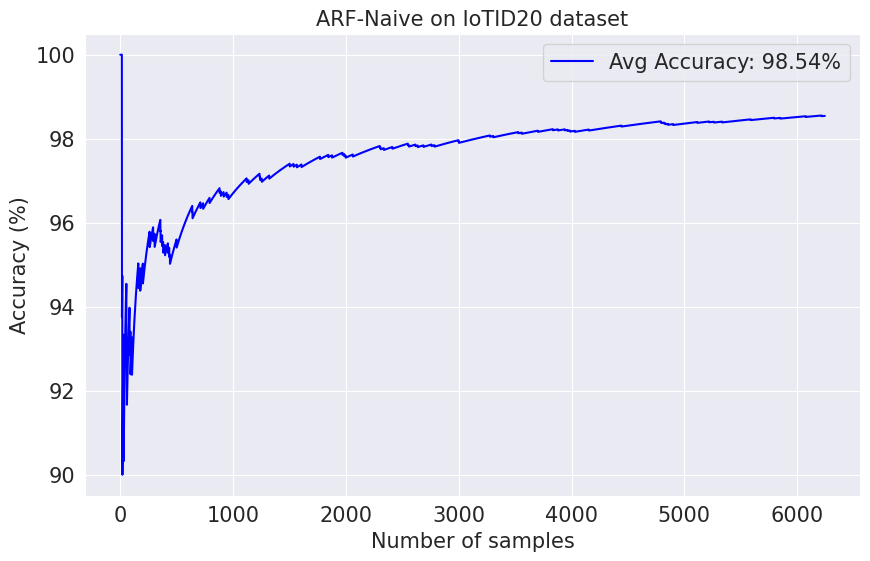


==== ARF ADVERSARIALLY-TRAINED Model Metrics ====
Accuracy:  98.783%
Precision: 98.873%
Recall:    99.847%
F1-score:  99.357%



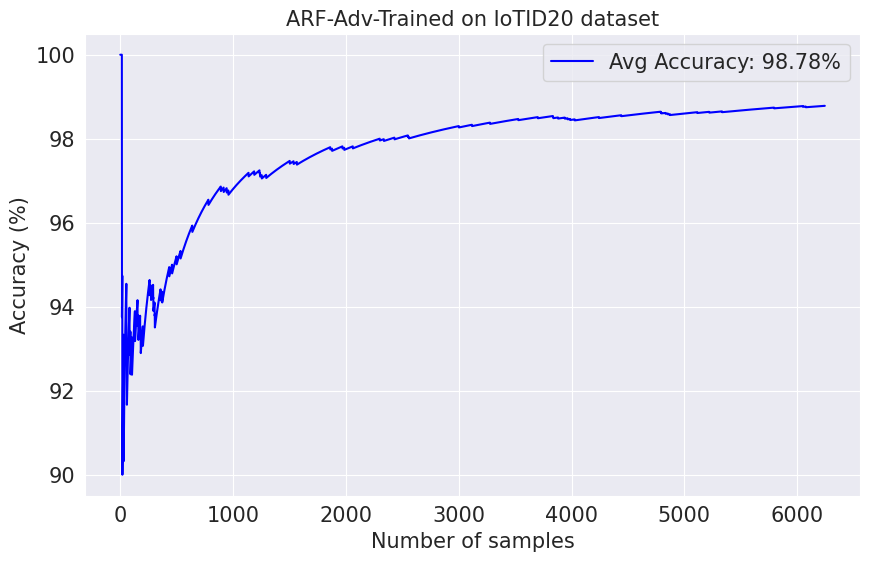

==== Cost-aware Adversarial Test: ARF (NAIVE) ====
Cost budget=0.00: Clean acc=0.9944, Adv acc=0.9944
Cost budget=0.05: Clean acc=0.9944, Adv acc=0.9944
Cost budget=0.10: Clean acc=0.9944, Adv acc=0.8220
Cost budget=0.20: Clean acc=0.9944, Adv acc=0.8220
Cost budget=0.40: Clean acc=0.9944, Adv acc=0.8220
Cost budget=0.80: Clean acc=0.9944, Adv acc=0.8220
Cost budget=1.00: Clean acc=0.9944, Adv acc=0.8220

==== Cost-aware Adversarial Test: ARF (ADV-TRAINED) ====
Cost budget=0.00: Clean acc=0.9944, Adv acc=0.9944
Cost budget=0.05: Clean acc=0.9944, Adv acc=0.9944
Cost budget=0.10: Clean acc=0.9944, Adv acc=0.9565
Cost budget=0.20: Clean acc=0.9944, Adv acc=0.9565
Cost budget=0.40: Clean acc=0.9944, Adv acc=0.9565
Cost budget=0.80: Clean acc=0.9944, Adv acc=0.9565
Cost budget=1.00: Clean acc=0.9944, Adv acc=0.9565



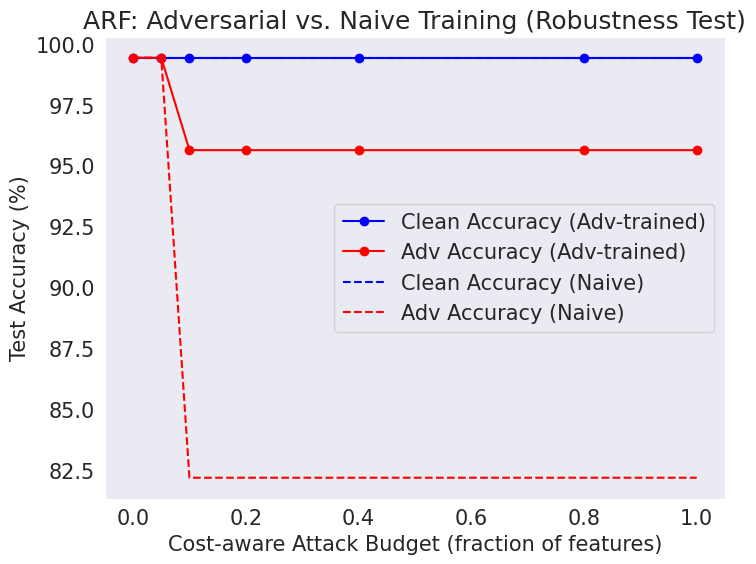

In [10]:
from river import ensemble, stream, metrics
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def acc_fig(t, m, name):
    plt.rcParams.update({'font.size': 15})
    plt.figure(1,figsize=(10,6))
    sns.set_style("darkgrid")
    plt.clf()
    plt.plot(t, m, '-b', label='Avg Accuracy: %.2f%%' % (m[-1]))
    plt.legend(loc='best')
    plt.title(name+' on IoTID20 dataset', fontsize=15)
    plt.xlabel('Number of samples')
    plt.ylabel('Accuracy (%)')
    plt.draw()
    plt.show()

# --- Standard training (naive ARF model) ---
def adaptive_learning(model, X_train, y_train, X_test, y_test):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== ARF NAIVE Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Adversarial training (adv-trained ARF model) ---
def adaptive_learning_adv(model, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges):
    metric = metrics.Accuracy()
    t, m, yt, yp = [], [], [], []
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi1)
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        y_pred = model.predict_one(dict(xi))
        model.learn_one(dict(xi), yi)
        x_adv = cost_aware_adversarial_example(dict(xi), yi, model, feature_costs, cost_budget, feature_ranges)
        model.learn_one(x_adv, yi)
        metric.update(yi, y_pred)
        t.append(i)
        m.append(metric.get()*100)
        yt.append(yi)
        yp.append(y_pred)

    print("\n==== ARF ADVERSARIALLY-TRAINED Model Metrics ====")
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)
    print(f"Accuracy:  {accuracy}%")
    print(f"Precision: {precision}%")
    print(f"Recall:    {recall}%")
    print(f"F1-score:  {f1}%")
    print("===========================================\n")
    return t, m, accuracy, precision, recall, f1

# --- Train models ---
model_arf_naive = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_naive, m_naive, _, _, _, _ = adaptive_learning(model_arf_naive, X_train, y_train, X_test, y_test)
acc_fig(t_naive, m_naive, "ARF-Naive")

model_arf_adv = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_adv, m_adv, _, _, _, _ = adaptive_learning_adv(model_arf_adv, X_train, y_train, X_test, y_test, feature_costs, cost_budget, feature_ranges)
acc_fig(t_adv, m_adv, "ARF-Adv-Trained")

# --- Evaluation under attack ---
def eval_under_attack(model, budgets, feature_costs, feature_ranges):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict_xi)
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model_arf_naive, budgets, feature_costs, feature_ranges)
results_adv = eval_under_attack(model_arf_adv, budgets, feature_costs, feature_ranges)

# ---- Print attack robustness with headings ---
print("==== Cost-aware Adversarial Test: ARF (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=============================================================\n")

print("==== Cost-aware Adversarial Test: ARF (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("===================================================================\n")

# --- Plot ---
plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('ARF: Adversarial vs. Naive Training (Robustness Test)')
plt.legend()
plt.grid()
plt.show()

# ARF Model with Time and Memory Metrics

In [11]:
from river import ensemble, stream
from memory_profiler import memory_usage
import time

# --- NAIVE ARF TRAINING PROFILED ---
model_arf_naive = ensemble.AdaptiveRandomForestClassifier(n_models=3)

def train_naive_arf():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model_arf_naive.learn_one(dict(xi1), yi1)

t0 = time.perf_counter()
peak_mem_train_naive = memory_usage((train_naive_arf,), max_usage=True, retval=False)
train_wall_naive = time.perf_counter() - t0
print(f"[NAIVE-ARF] Training wall time (s): {train_wall_naive:.4f} | Peak mem.: {peak_mem_train_naive:.2f} MB")

# --- NAIVE ARF PREDICTION PROFILED ---
def pred_naive_arf():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model_arf_naive.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_naive = memory_usage((pred_naive_arf,), max_usage=True, retval=True)
pred_wall_naive = time.perf_counter() - t0
peak_mem_pred_naive = mem_pred_naive[0]
yt, yp = mem_pred_naive[1]
pred_times_naive = pred_wall_naive / len(yt) if len(yt) > 0 else float('nan')
print(f"[NAIVE-ARF] Prediction wall time (s): {pred_wall_naive:.4f} | Peak mem.: {peak_mem_pred_naive:.2f} MB")
print(f"[NAIVE-ARF] Avg prediction time/sample (ms): {pred_times_naive*1000:.4f}")

# --- ADV ARF TRAINING PROFILED ---
model_arf_adv = ensemble.AdaptiveRandomForestClassifier(n_models=3)
def train_adv_arf():
    for xi1, yi1 in stream.iter_pandas(X_train, y_train):
        model_arf_adv.learn_one(dict(xi1), yi1)
        x_adv = cost_aware_adversarial_example(
            dict(xi1), yi1, model_arf_adv, feature_costs, cost_budget, feature_ranges
        )
        model_arf_adv.learn_one(x_adv, yi1)

t0 = time.perf_counter()
peak_mem_train_adv = memory_usage((train_adv_arf,), max_usage=True, retval=False)
train_wall_adv = time.perf_counter() - t0
print(f"[ADV-TRAINED-ARF] Training wall time (s): {train_wall_adv:.4f} | Peak mem.: {peak_mem_train_adv:.2f} MB")

# --- ADV ARF PREDICTION PROFILED ---
def pred_adv_arf():
    yt, yp = [], []
    for xi, yi in stream.iter_pandas(X_test, y_test):
        y_pred = model_arf_adv.predict_one(dict(xi))
        yt.append(yi)
        yp.append(y_pred)
    return yt, yp

t0 = time.perf_counter()
mem_pred_adv = memory_usage((pred_adv_arf,), max_usage=True, retval=True)
pred_wall_adv = time.perf_counter() - t0
peak_mem_pred_adv = mem_pred_adv[0]
yt_adv, yp_adv = mem_pred_adv[1]
pred_times_adv = pred_wall_adv / len(yt_adv) if len(yt_adv) > 0 else float('nan')
print(f"[ADV-TRAINED-ARF] Prediction wall time (s): {pred_wall_adv:.4f} | Peak mem.: {peak_mem_pred_adv:.2f} MB")
print(f"[ADV-TRAINED-ARF] Avg prediction time/sample (ms): {pred_times_adv*1000:.4f}")

# --- SUMMARY ---
print("\n==== Timing & Peak Memory Summary for Adaptive Random Forest ====")
print(f"Train time (s):         Naive={train_wall_naive:.3f} | Adv-trained={train_wall_adv:.3f}")
print(f"Train peak mem (MB):    Naive={peak_mem_train_naive:.2f} | Adv-trained={peak_mem_train_adv:.2f}")
print(f"Pred time (s):          Naive={pred_wall_naive:.3f} | Adv-trained={pred_wall_adv:.3f}")
print(f"Pred peak mem (MB):     Naive={peak_mem_pred_naive:.2f} | Adv-trained={peak_mem_pred_adv:.2f}")
print(f"Avg pred/sample (ms):   Naive={pred_times_naive*1000:.3f} | Adv-trained={pred_times_adv*1000:.3f}")
print("=====================================\n")

[NAIVE-ARF] Training wall time (s): 0.1877 | Peak mem.: 516.64 MB
[NAIVE-ARF] Prediction wall time (s): 0.5706 | Peak mem.: 516.64 MB
[NAIVE-ARF] Avg prediction time/sample (ms): 0.0914
[ADV-TRAINED-ARF] Training wall time (s): 0.2273 | Peak mem.: 516.64 MB
[ADV-TRAINED-ARF] Prediction wall time (s): 0.5018 | Peak mem.: 516.64 MB
[ADV-TRAINED-ARF] Avg prediction time/sample (ms): 0.0803

==== Timing & Peak Memory Summary for Adaptive Random Forest ====
Train time (s):         Naive=0.188 | Adv-trained=0.227
Train peak mem (MB):    Naive=516.64 | Adv-trained=516.64
Pred time (s):          Naive=0.571 | Adv-trained=0.502
Pred peak mem (MB):     Naive=516.64 | Adv-trained=516.64
Avg pred/sample (ms):   Naive=0.091 | Adv-trained=0.080



# ARF Model and Drift Detection

#ARF and Drift Detection with DDM

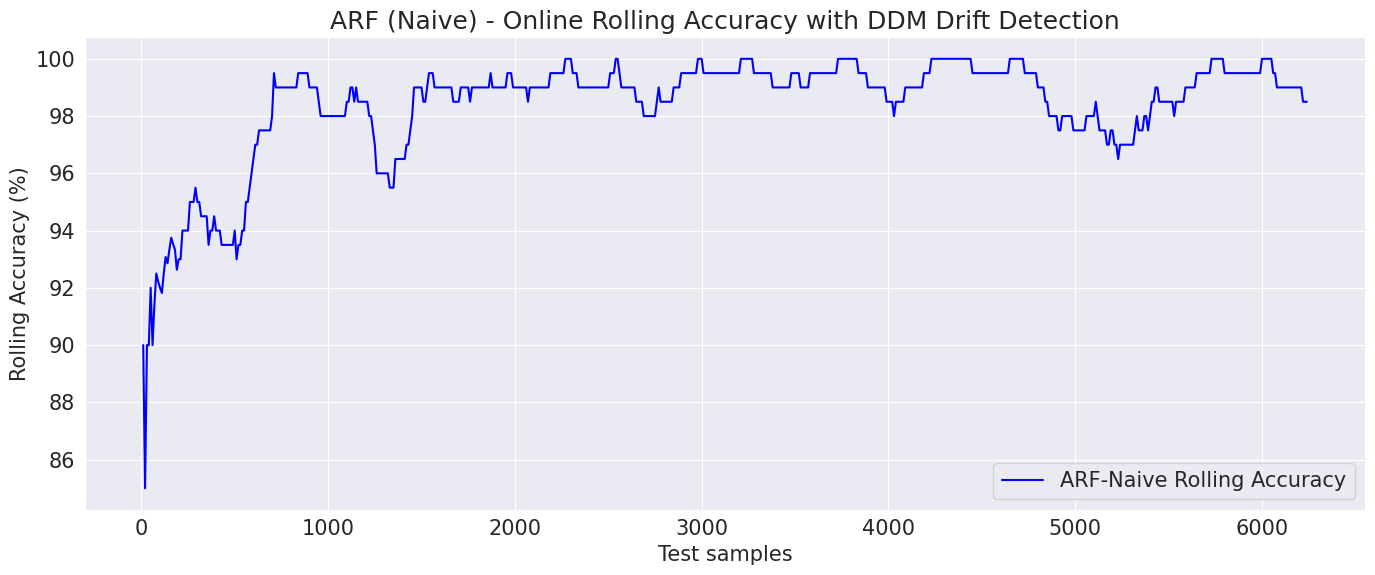

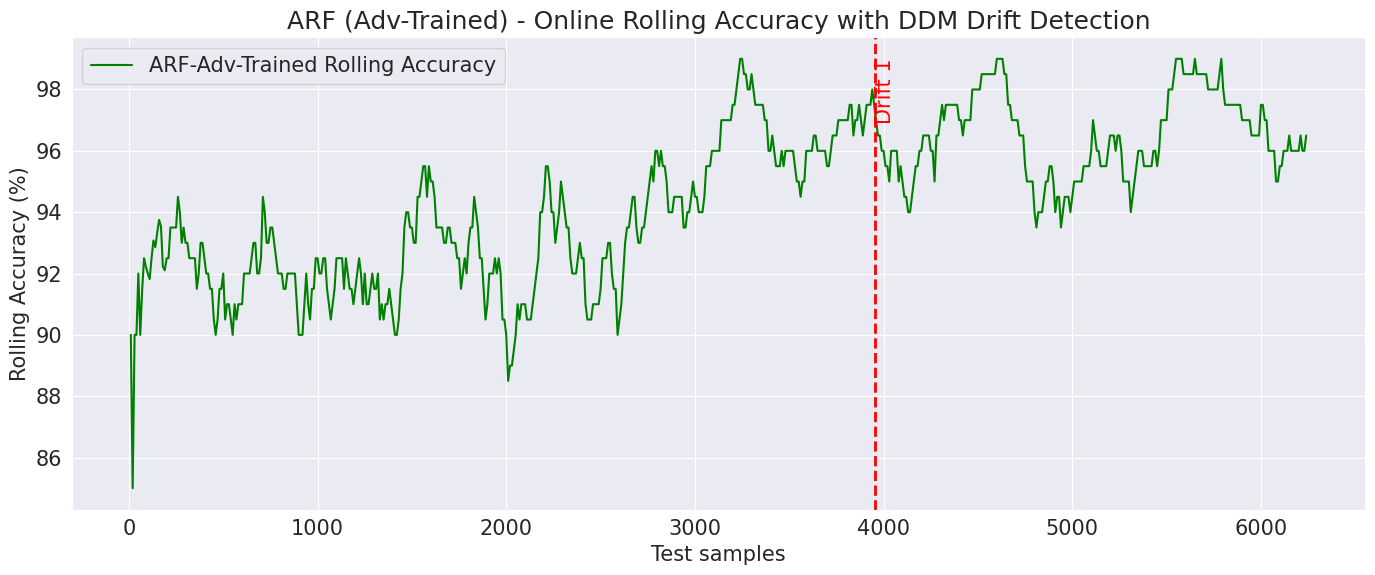

In [16]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='DDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for ARF (NAIVE) --
model_arf_naive = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_arf_naive, X_test, y_test, drift_type='DDM', adv=False, label="ARF-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="ARF-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Naive) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for ARF (ADV-TRAINED) --
model_arf_adv = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_arf_adv, X_test, y_test, drift_type='DDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="ARF-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="ARF-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Adv-Trained) - Online Rolling Accuracy with DDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ARF Drift Detection with ADWIN

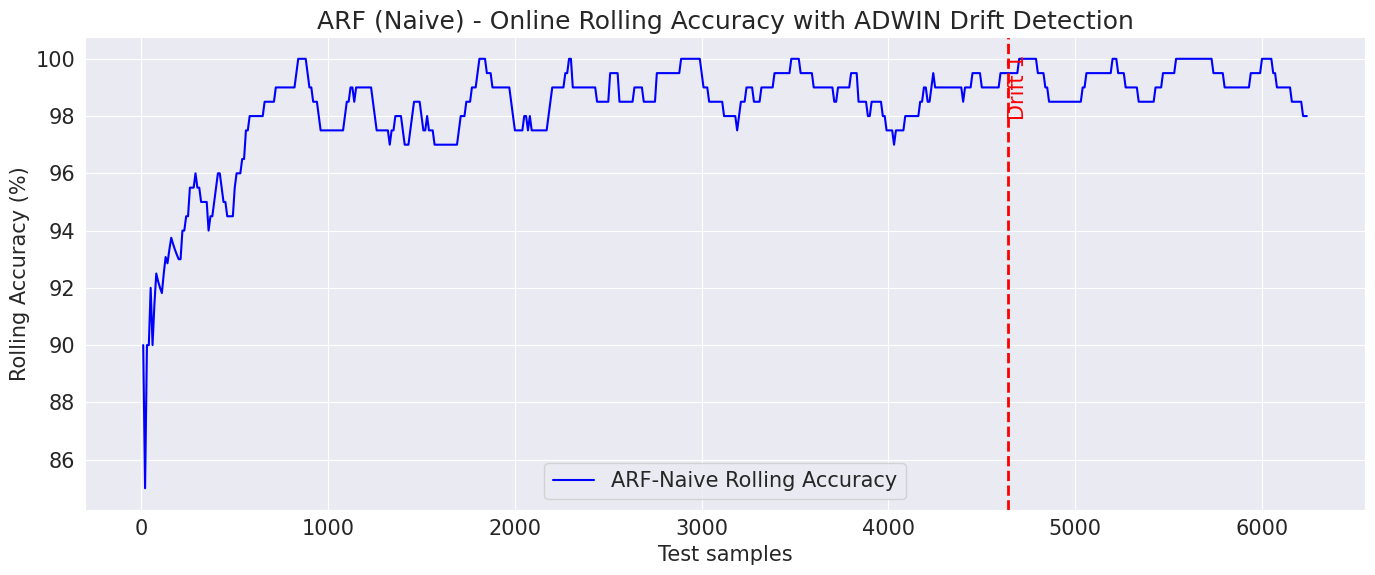

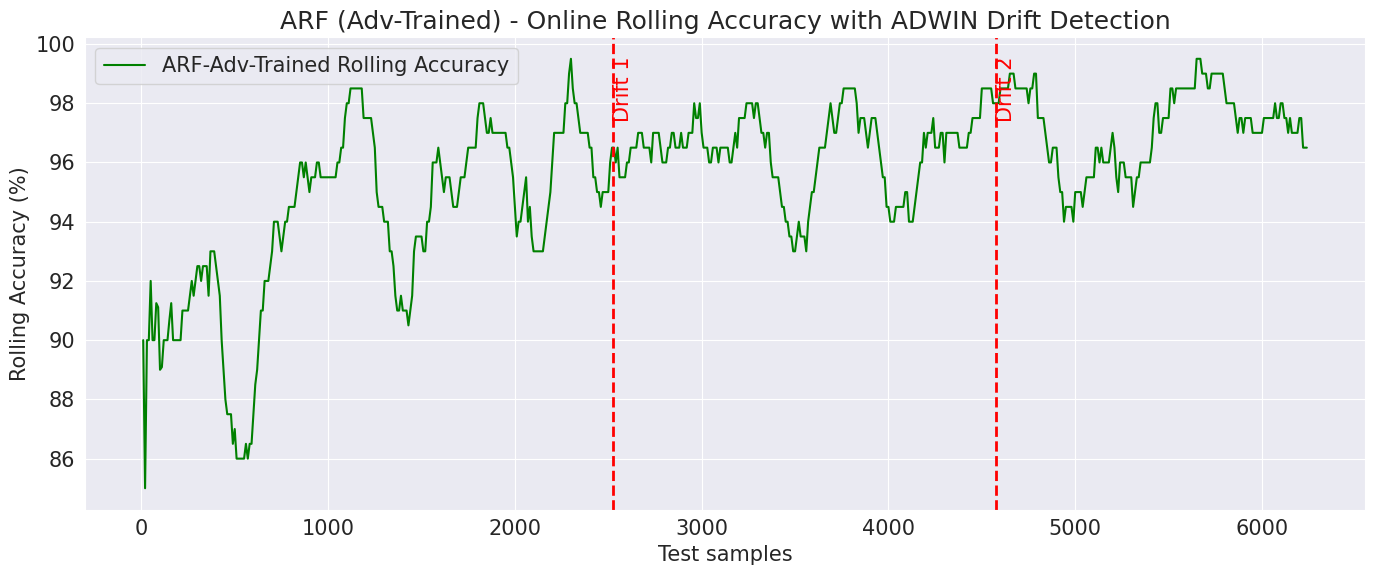

In [14]:
!pip install river
import numpy as np
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='ADWIN',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- Example for ARF (NAIVE) --
model_arf_naive = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_arf_naive, X_test, y_test, drift_type='ADWIN', adv=False, label="ARF-Naive"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="ARF-Naive Rolling Accuracy", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Naive) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- Example for ARF (ADV-TRAINED) --
model_arf_adv = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_arf_adv, X_test, y_test, drift_type='ADWIN',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="ARF-Adv-Trained"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="ARF-Adv-Trained Rolling Accuracy", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Adv-Trained) - Online Rolling Accuracy with ADWIN Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# ARP Drift Detection with EDDM

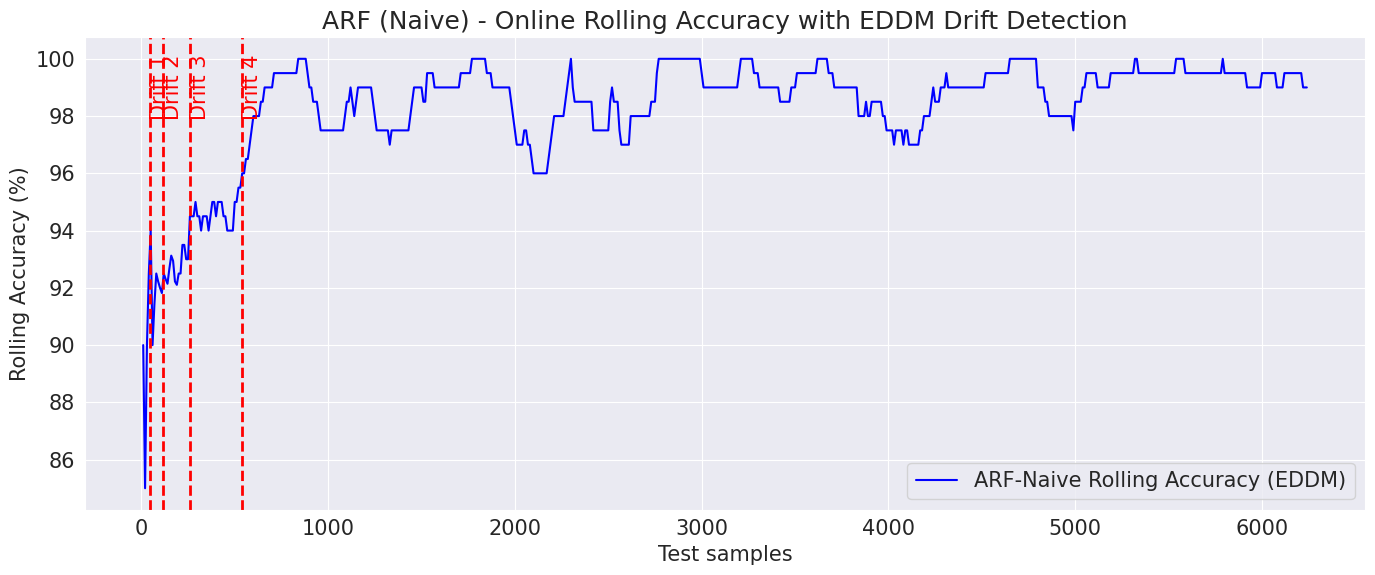

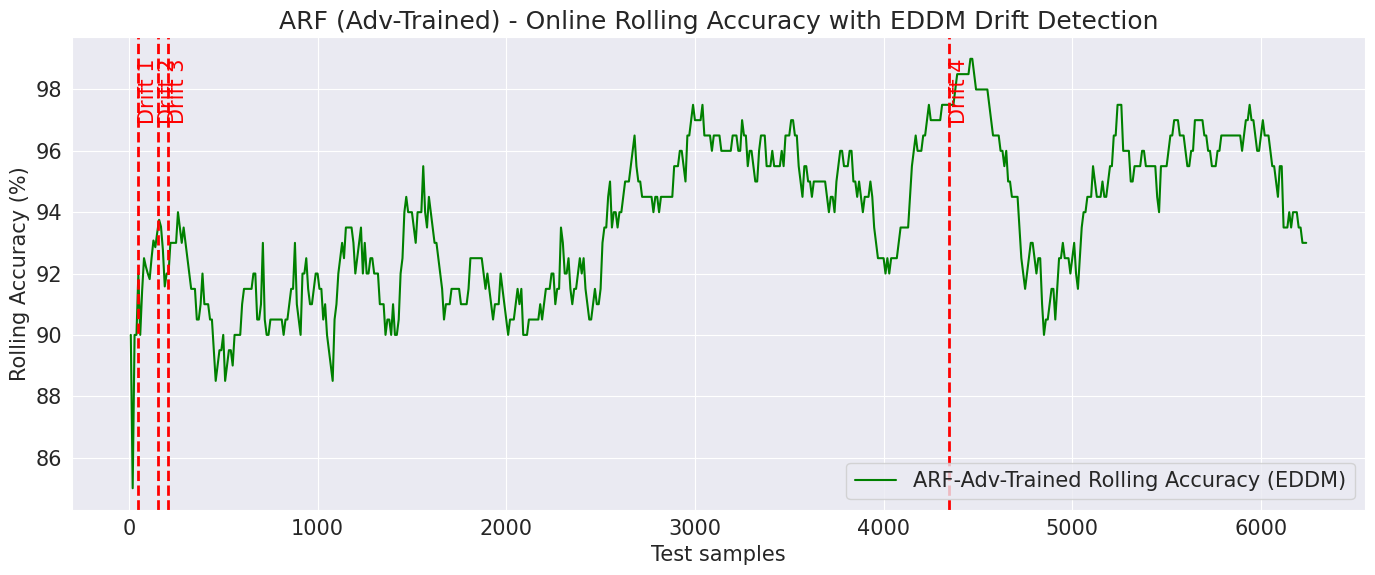

In [15]:
from river.drift import DDM, EDDM, ADWIN
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, ensemble

def online_accuracy_with_drift(
    model, X_test, y_test, drift_type='EDDM',
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None,
    rollwin=200, label="Model"
):
    detector = {'DDM': DDM(), 'EDDM': EDDM(), 'ADWIN': ADWIN()}[drift_type]
    rolling_acc = []
    t_idx = []
    yt, yp = [], []
    drift_points = []
    for i, (xi, yi) in enumerate(stream.iter_pandas(X_test, y_test)):
        x_input = dict(xi)
        if adv:
            x_input = cost_aware_adversarial_example(
                x_input, yi, model, feature_costs, cost_budget, feature_ranges
            )
        y_pred = model.predict_one(x_input)
        yp.append(y_pred)
        yt.append(yi)
        is_correct = int(y_pred == yi)
        detector.update(is_correct)
        if detector.change_detected:
            drift_points.append(i)
        model.learn_one(x_input, yi)
        if i > 0 and (i % 10 == 0):
            starti = max(0, i-rollwin)
            acc = np.mean(np.array(yt[starti:i]) == np.array(yp[starti:i])) * 100
            rolling_acc.append(acc)
            t_idx.append(i)
    return t_idx, rolling_acc, drift_points

# --- ARF (NAIVE) ---
model_arf_naive = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_naive, acc_naive, drift_naive = online_accuracy_with_drift(
    model_arf_naive, X_test, y_test, drift_type='EDDM', adv=False, label="ARF-Naive (EDDM)"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_naive, acc_naive, label="ARF-Naive Rolling Accuracy (EDDM)", color="b")
for j, drift in enumerate(drift_naive):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_naive)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Naive) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# --- ARF (ADV-TRAINED) ---
model_arf_adv = ensemble.AdaptiveRandomForestClassifier(n_models=3)
t_adv, acc_adv, drift_adv = online_accuracy_with_drift(
    model_arf_adv, X_test, y_test, drift_type='EDDM',
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    label="ARF-Adv-Trained (EDDM)"
)

plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
plt.plot(t_adv, acc_adv, label="ARF-Adv-Trained Rolling Accuracy (EDDM)", color="g")
for j, drift in enumerate(drift_adv):
    plt.axvline(x=drift, color='red', linestyle='--', linewidth=2)
    plt.text(drift, max(acc_adv)*0.98, f'Drift {j+1}', color='red', fontsize=15, rotation=90)
plt.title("ARF (Adv-Trained) - Online Rolling Accuracy with EDDM Drift Detection")
plt.xlabel("Test samples")
plt.ylabel("Rolling Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

# Testing SRP with Peak Memory so I can check the Timing Metrics of the Above SRP without it.


==== SRP (Naive) Metrics ====
Accuracy:         94.22%
Precision:        94.22%
Recall:           100.0%
F1-score:         97.024%
------
Training wall time (s): 0.121
Peak mem during train (MB): 554.49
Prediction (total) wall time (s): 12879.934
Average prediction time/sample (ms): 1031.069
Peak memory during prediction (MB): 556.25


==== SRP (Adv-Trained) Metrics ====
Accuracy:         94.22%
Precision:        94.22%
Recall:           100.0%
F1-score:         97.024%
------
Training wall time (s): 0.154
Peak mem during train (MB): 556.25
Prediction (total) wall time (s): 12864.571
Average prediction time/sample (ms): 1029.914
Peak memory during prediction (MB): 556.43

==== Cost-aware Adversarial Test: SRP (NAIVE) ====
Cost budget=0.00: Clean acc=0.9422, Adv acc=0.9422
Cost budget=0.05: Clean acc=0.9422, Adv acc=0.9422
Cost budget=0.10: Clean acc=0.9422, Adv acc=0.9422
Cost budget=0.20: Clean acc=0.9422, Adv acc=0.9422
Cost budget=0.40: Clean acc=0.9422, Adv acc=0.9422
Cost budget=

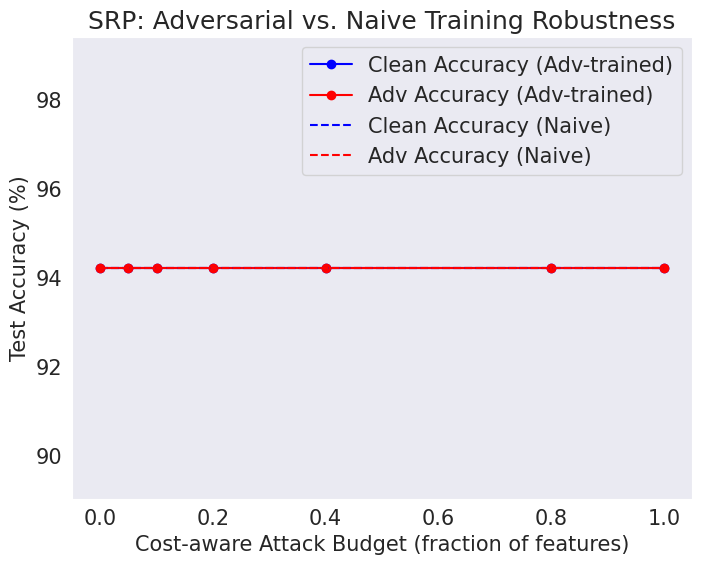

In [35]:
# === 1. Setup ===
!pip install memory_profiler
from memory_profiler import memory_usage
from river import ensemble, tree, stream
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# === 2. Profiling and Training Utility Function ===
def train_and_profile(
    model, X_train, y_train, X_test, y_test,
    adv=False, feature_costs=None, cost_budget=None, feature_ranges=None, name='Model'
):
    yt, yp = [], []

    # --- Training ---
    def train_func():
        for xi1, yi1 in stream.iter_pandas(X_train, y_train):
            model.learn_one(dict(xi1), yi1)
            if adv:
                x_adv = cost_aware_adversarial_example(
                    dict(xi1), yi1, model, feature_costs, cost_budget, feature_ranges
                )
                model.learn_one(x_adv, yi1)

    t0 = time.perf_counter()
    train_peak_mem = memory_usage((train_func, ), max_usage=True, retval=False)
    train_wall = time.perf_counter() - t0

    # --- Prediction ---
    n_test = 0
    pred_times = []
    mem_pred = []
    t_pred0 = time.perf_counter()
    for xi, yi in stream.iter_pandas(X_test, y_test):
        t1 = time.perf_counter()
        mem0 = memory_usage(-1, interval=0.01, timeout=1, max_usage=True) # Removed [0]
        y_pred = model.predict_one(dict(xi))
        t2 = time.perf_counter()
        mem1 = memory_usage(-1, interval=0.01, timeout=1, max_usage=True) # Removed [0]
        yt.append(yi)
        yp.append(y_pred)
        pred_times.append(t2-t1)
        mem_pred.append(mem1)
        n_test += 1
    pred_wall = time.perf_counter() - t_pred0
    avg_pred_time = np.mean(pred_times) if pred_times else float('nan')
    peak_pred_mem = np.max(mem_pred) if mem_pred else None

    # --- Metrics ---
    accuracy = round(accuracy_score(yt, yp)*100, 3)
    precision = round(precision_score(yt, yp)*100, 3)
    recall = round(recall_score(yt, yp)*100, 3)
    f1 = round(f1_score(yt, yp)*100, 3)

    print(f"\n==== {name} Metrics ====")
    print(f"Accuracy:         {accuracy}%")
    print(f"Precision:        {precision}%")
    print(f"Recall:           {recall}%")
    print(f"F1-score:         {f1}%")
    print("------")
    print(f"Training wall time (s): {train_wall:.3f}")
    print(f"Peak mem during train (MB): {train_peak_mem:.2f}")
    print(f"Prediction (total) wall time (s): {pred_wall:.3f}")
    print(f"Average prediction time/sample (ms): {avg_pred_time*1000:.3f}")
    print(f"Peak memory during prediction (MB): {peak_pred_mem:.2f}" if peak_pred_mem else "")
    print("===================================\n")
    return model  # Return trained model for attack eval

# === 3. Robustness Evaluation Function ===
def eval_under_attack(model, budgets, feature_costs, feature_ranges, X_test, y_test):
    results = []
    for frac in budgets:
        adv_budget = frac * len(feature_costs)
        y_true, y_pred_clean, y_pred_adv = [], [], []
        for xi, yi in stream.iter_pandas(X_test, y_test):
            dict_xi = dict(xi)
            y_pred = model.predict_one(dict(xi))
            x_adv = cost_aware_adversarial_example(dict_xi, yi, model, feature_costs, adv_budget, feature_ranges)
            y_pred_a = model.predict_one(x_adv)
            y_true.append(yi)
            y_pred_clean.append(y_pred)
            y_pred_adv.append(y_pred_a)
        clean_acc = accuracy_score(y_true, y_pred_clean)
        adv_acc = accuracy_score(y_true, y_pred_adv)
        results.append((frac, clean_acc, adv_acc))
    return np.array(results)

# === 4. Train & Profile SRP Models ===
model4_naive = ensemble.SRPClassifier(n_models=3)
model4_naive = train_and_profile(
    model4_naive, X_train, y_train, X_test, y_test,
    adv=False, name="SRP (Naive)"
)

model4_adv = ensemble.SRPClassifier(n_models=3)
model4_adv = train_and_profile(
    model4_adv, X_train, y_train, X_test, y_test,
    adv=True, feature_costs=feature_costs, cost_budget=cost_budget, feature_ranges=feature_ranges,
    name="SRP (Adv-Trained)"
)

# === 5. Evaluate Robustness and Plot ===
budgets = [0.0, 0.05, 0.10, 0.20, 0.40, 0.80, 1.0]
results_naive = eval_under_attack(model4_naive, budgets, feature_costs, feature_ranges, X_test, y_test)
results_adv = eval_under_attack(model4_adv, budgets, feature_costs, feature_ranges, X_test, y_test)

print("==== Cost-aware Adversarial Test: SRP (NAIVE) ====")
for frac, clean_acc, adv_acc in results_naive:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("==================================================\n")

print("==== Cost-aware Adversarial Test: SRP (ADV-TRAINED) ====")
for frac, clean_acc, adv_acc in results_adv:
    print(f"Cost budget={frac:.2f}: Clean acc={clean_acc:.4f}, Adv acc={adv_acc:.4f}")
print("=======================================================\n")

plt.figure(figsize=(8,6))
plt.plot(results_adv[:,0], results_adv[:,1]*100, 'bo-', label='Clean Accuracy (Adv-trained)')
plt.plot(results_adv[:,0], results_adv[:,2]*100, 'ro-', label='Adv Accuracy (Adv-trained)')
plt.plot(results_naive[:,0], results_naive[:,1]*100, 'b--', label='Clean Accuracy (Naive)')
plt.plot(results_naive[:,0], results_naive[:,2]*100, 'r--', label='Adv Accuracy (Naive)')
plt.xlabel('Cost-aware Attack Budget (fraction of features)')
plt.ylabel('Test Accuracy (%)')
plt.title('SRP: Adversarial vs. Naive Training Robustness')
plt.legend()
plt.grid()
plt.show()


# Explainability